# **FIT5196 - Task 1. Data Cleansing — Group 102**
### **Overview**
- **Goal**: Clean/validate three inputs (dirty / missing / outlier) into three submission CSVs with rule-driven, reproducible steps.
- **Scope**: EDA (graphical + non-graphical) → Dirty (**one anomaly per row**) → Missing (**coverage only**) → Outlier (**delivery_charges only**). :contentReference[oaicite:2]{index=2}
- **Evidence**: lightweight visuals, per-season model diagnostics (R^2≈1), and post-export read-back checks.
- **Compliance**: exact columns/order; filenames per spec; parsable outputs; no newly introduced errors. :contentReference[oaicite:3]{index=3} :contentReference[oaicite:4]{index=4}

---


#### Group 102:
Member 1: Yuwei Cong, (34549803), ycon0004@student.monash.edu

Member 2: Peter Sung, (33733376), psun0014@student.monash.edu

Member 3: Ying Luo, (34654089), yluo0102@student.monash.edu  

---


## Table of Contents


---

1. [Setup](#setup)
2. [Load Data](#load-data)
3. [Exploratory Data Analysis](#exploratory-data-analysis)
3. [Data Cleansing](#data-cleansing)
    - [Dirty Data Handling](#dirty-data-handling)
        - [Anomaly Detection](#anomaly-detection)
        - [Anomaly Resolution](#anomaly-resolution)
        - [Anomaly Correction](#anomaly-correction)
    - [Missing Data Handling](#missing-data-handling)
    - [Outlier Data Handling](#outlier-data-handling)
4. [Export Cleaned Data](#export-cleaned-data)




## SECTION 1: SETUP AND ENVIRONMENT CONFIGURATION

In [1]:
# ==== 1.1 Mount Google Drive ====
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
    print("Google Drive mounted\n")
except:
    IN_COLAB = False
    print("Not in Colab\n")

# ==== 1.2 Import Libraries ====
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import re
import ast

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# NLTK
import nltk
warnings.filterwarnings("ignore")

# IPython display compatibility
try:
    from IPython.display import display
except:
    def display(*args, **kwargs):
        for arg in args:
            print(arg)

# Set random seed for reproducibility
np.random.seed(5196)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

print("OK - All libraries imported successfully\n")

# ==== 1.3 Configure Paths (Hard-coded) ====
GROUP_ID = "102"

# Input paths (read-only shared drive)
BASE = '/content/drive/Shareddrives/FIT5196_S2_2025/Assessment2'
GROUP = os.path.join(BASE, 'student_data', f'Group{GROUP_ID}')

# Output path (writable local directory)
OUT = "/content/outputs" if IN_COLAB else "./outputs"
os.makedirs(OUT, exist_ok=True)

print("=" * 60)
print("PATH CONFIGURATION")
print("=" * 60)
print(f"Group ID    : {GROUP_ID}")
print(f"Input Dir   : {GROUP}")
print(f"Warehouse   : {BASE}/warehouses.csv")
print(f"Output Dir  : {OUT}")
print("=" * 60 + "\n")

# ==== 1.4 Download VADER lexicon ====
try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    nltk.download('vader_lexicon', quiet=True)
    _SENTIMENT_ANALYZER = SentimentIntensityAnalyzer()
    print("OK - VADER sentiment analyzer ready\n")
except Exception as e:
    print(f"VADER initialization warning: {e}\n")

print("OK - SETUP COMPLETE\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted

OK - All libraries imported successfully

PATH CONFIGURATION
Group ID    : 102
Input Dir   : /content/drive/Shareddrives/FIT5196_S2_2025/Assessment2/student_data/Group102
Warehouse   : /content/drive/Shareddrives/FIT5196_S2_2025/Assessment2/warehouses.csv
Output Dir  : /content/outputs

OK - VADER sentiment analyzer ready

OK - SETUP COMPLETE



## SECTION 2: LOAD DATA AND INITIAL PROFILING

**Inputs & Outputs (Table 1/2 compliance)**
- **Inputs**: `Group_102_dirty_data.csv`, `Group_102_missing_data.csv`, `Group_102_outlier_data.csv`, `warehouses.csv`  
- **Outputs**: `Group_102_dirty_data_solution.csv`, `Group_102_missing_data_solution.csv`, `Group_102_outlier_data_solution.csv`  
- **Spec notes**:  
  - Output columns must **exactly** match inputs (names & order) — otherwise auto-marker fails. :contentReference[oaicite:5]{index=5}  
  - Dirty: **≤1 anomaly per row**, and **one unique fix**; error-free columns：`coupon_discount`, `delivery_charges`, quantities in `shopping_cart`, `order_id`, `customer_id`, `latest_customer_review`. :contentReference[oaicite:6]{index=6}  


In [2]:
# === QA Helpers (added) ===
import re, pandas as pd

def overview(df: pd.DataFrame, name: str):
    print(f"\n=== OVERVIEW: {name} ===")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} cols")
    na = df.isna().sum()
    na = na[na>0].sort_values(ascending=False)
    if len(na):
        print("NA counts (top 8):")
        print(na.head(8))
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if num_cols:
        desc = df[num_cols].describe().T[["mean","std","min","max"]].round(3)
        print("\nNumeric summary (head):")
        print(desc.head(8))

def read_back_and_assert(path: str, expected_cols: list, money_cols=None, dist_col=None):
    chk = pd.read_csv(path)
    assert list(chk.columns) == expected_cols, f"Column order mismatch in {path}"
    if money_cols:
        for c in money_cols:
            # ensure 2 dp
            assert chk[c].astype(str).str.contains(r"^\d+(\.\d{1,2})?$", regex=True).all(), f"{c} not 2dp in {path}"
    if dist_col:
        assert chk[dist_col].astype(str).str.contains(r"^\d+(\.\d{1,3})?$", regex=True).all(), f"{dist_col} not 3dp in {path}"
    print(f"[OK] Read-back passed: {os.path.basename(path)}")
    return chk

In [3]:
print()
print("\n" + "="*80)
print("*** SECTION 2: LOAD DATA AND INITIAL PROFILING ***")
print("="*80 + "\n")



*** SECTION 2: LOAD DATA AND INITIAL PROFILING ***



In [4]:
# ==== 2.1 Check Directory Structure (Diagnostic) ====
print("🔍 Checking directory structure...")

if os.path.exists(BASE):
    print(f"  Assessment2 root: {BASE}")
    base_files = [f for f in os.listdir(BASE) if f.endswith('.csv')]
    print(f"    CSV files: {base_files}")
else:
    print(f"  Assessment2 root NOT found: {BASE}")

if os.path.exists(GROUP):
    print(f"  Group102 folder: {GROUP}")
    group_files = os.listdir(GROUP)
    print(f"    Files: {group_files}")
else:
    print(f"  Group102 folder NOT found: {GROUP}")

print()

# ==== 2.2 Load Datasets ====
try:
    # Student data (in Group102 subfolder)
    dirty_df = pd.read_csv(os.path.join(GROUP, f'Group_{GROUP_ID}_dirty_data.csv'))
    print(f"OK - dirty_data   : {dirty_df.shape}")

    missing_df = pd.read_csv(os.path.join(GROUP, f'Group_{GROUP_ID}_missing_data.csv'))
    print(f"OK - missing_data : {missing_df.shape}")

    outlier_df = pd.read_csv(os.path.join(GROUP, f'Group_{GROUP_ID}_outlier_data.csv'))
    print(f"OK - outlier_data : {outlier_df.shape}")

    # Warehouses (in Assessment2 root, NOT in Group102)
    ware_df = pd.read_csv(os.path.join(BASE, 'warehouses.csv'))
    print(f"OK - warehouses   : {ware_df.shape}")

    # Store original column orders (CRITICAL for output)
    dirty_cols = list(dirty_df.columns)
    missing_cols = list(missing_df.columns)
    outlier_cols = list(outlier_df.columns)

    print("\nOK - ALL DATASETS LOADED SUCCESSFULLY")

except FileNotFoundError as e:
    print(f"\n FILE NOT FOUND: {e}")
    print("\n TROUBLESHOOTING:")
    print("  1. Ensure Drive is mounted:")
    print("     from google.colab import drive")
    print("     drive.mount('/content/drive')")
    print("\n  2. Add shared folder to 'My Drive':")
    print("     https://drive.google.com/drive/folders/1BPctN9TKkYYjl6vJK9zY-2sy0k_1mClB")
    print("     Right-click → 'Add shortcut to Drive' → My Drive")
    print("\n  3. Re-run this cell")
    raise

print("=" * 80 + "\n")

# ==== 2.3 Display Loaded Data ====
print(f"Loaded dirty_data   : {dirty_df.shape}")
print(f"Loaded missing_data : {missing_df.shape}")
print(f"Loaded outlier_data : {outlier_df.shape}")
print(f"Loaded warehouses   : {ware_df.shape}\n")

print("Warehouse Reference Data:")
display(ware_df)
print("\n")

🔍 Checking directory structure...
  Assessment2 root: /content/drive/Shareddrives/FIT5196_S2_2025/Assessment2
    CSV files: ['warehouses.csv']
  Group102 folder: /content/drive/Shareddrives/FIT5196_S2_2025/Assessment2/student_data/Group102
    Files: ['Group_102_dirty_data.csv', 'Group_102_missing_data.csv', 'Group_102_outlier_data.csv']

OK - dirty_data   : (500, 16)
OK - missing_data : (500, 16)
OK - outlier_data : (500, 16)
OK - warehouses   : (3, 3)

OK - ALL DATASETS LOADED SUCCESSFULLY

Loaded dirty_data   : (500, 16)
Loaded missing_data : (500, 16)
Loaded outlier_data : (500, 16)
Loaded warehouses   : (3, 3)

Warehouse Reference Data:


,names,lat,lon
0,Nickolson,-37.818595,144.969551
1,Thompson,-37.812673,144.947069
2,Bakers,-37.809996,144.995232


### 2.3 Store original column orders (CRITICAL for output)

In [5]:
dirty_cols   = list(dirty_df.columns)
missing_cols = list(missing_df.columns)
outlier_cols = list(outlier_df.columns)

print(f" Loaded dirty_data:   {dirty_df.shape}")
print(f" Loaded missing_data: {missing_df.shape}")
print(f" Loaded outlier_data: {outlier_df.shape}")
print(f" Loaded warehouses:   {ware_df.shape}\n")

 Loaded dirty_data:   (500, 16)
 Loaded missing_data: (500, 16)
 Loaded outlier_data: (500, 16)
 Loaded warehouses:   (3, 3)



### 2.4 Display warehouse reference

In [6]:
print("Warehouse Reference Data:")
display(ware_df)
print("\n")

Warehouse Reference Data:


,names,lat,lon
0,Nickolson,-37.818595,144.969551
1,Thompson,-37.812673,144.947069
2,Bakers,-37.809996,144.995232


### 2.5 Quick profiling function

In [7]:
def profile_dataset(df, name):
    """Generate comprehensive profile of a dataset."""
    print(f"\n{'='*70}")
    print(f"PROFILE: {name}")

    print(f"\n Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    print(f"\n Data Types:")
    dtype_summary = df.dtypes.value_counts()
    for dtype, count in dtype_summary.items():
        print(f"  {dtype}: {count} columns")

    print(f"\n Missing Values:")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) == 0:
        print("  No missing values detected")
    else:
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f"  {col}: {count} ({pct:.1f}%)")

    print(f"\n Numeric Summary:")
    display(df.describe(include='number').T[['count', 'mean', 'std', 'min', 'max']].head(10))

    print(f"\n Categorical Summary:")
    cat_cols = df.select_dtypes(include=['object', 'bool']).columns[:5]
    for col in cat_cols:
        unique = df[col].nunique()
        print(f"  {col}: {unique} unique values")
        if unique <= 10:
            print(f"    Values: {df[col].value_counts().to_dict()}")

# Profile all datasets
profile_dataset(dirty_df, "DIRTY DATA")
profile_dataset(missing_df, "MISSING DATA")
profile_dataset(outlier_df, "OUTLIER DATA")

print("INITIAL PROFILING COMPLETE")
print("="*80 + "\n\n")


PROFILE: DIRTY DATA

 Shape: 500 rows × 16 columns

 Data Types:
  object: 7 columns
  float64: 5 columns
  int64: 2 columns
  bool: 2 columns

 Missing Values:
  latest_customer_review: 1 (0.2%)

 Numeric Summary:


,count,mean,std,min,max
order_price,500.0,13269.790000,8246.456730,1010.000000,41340.000000
delivery_charges,500.0,76.304900,14.728203,44.270000,109.570000
customer_lat,500.0,-27.942660,41.353342,-37.826276,145.016424
customer_long,500.0,135.098025,41.352835,-37.824531,145.016195
coupon_discount,500.0,11.180000,8.440977,0.000000,25.000000
order_total,500.0,11891.036200,7428.974849,1071.610000,39652.320000
distance_to_nearest_warehouse,500.0,1.060340,0.471394,0.057000,3.433200



 Categorical Summary:
  order_id: 500 unique values
  customer_id: 496 unique values
  date: 292 unique values
  nearest_warehouse: 6 unique values
    Values: {'Thompson': 190, 'Nickolson': 166, 'Bakers': 123, 'thompson': 10, 'nickolson': 8, 'bakers': 3}
  shopping_cart: 466 unique values

PROFILE: MISSING DATA

 Shape: 500 rows × 16 columns

 Data Types:
  object: 7 columns
  float64: 7 columns
  int64: 1 columns
  bool: 1 columns

 Missing Values:
  nearest_warehouse: 55 (11.0%)
  delivery_charges: 40 (8.0%)
  is_happy_customer: 40 (8.0%)
  distance_to_nearest_warehouse: 31 (6.2%)
  order_price: 15 (3.0%)
  order_total: 15 (3.0%)

 Numeric Summary:


,count,mean,std,min,max
order_price,485.0,13348.927835,7815.914535,580.000000,41870.000000
delivery_charges,460.0,77.578435,14.667043,48.400000,115.020000
customer_lat,500.0,-37.812129,0.007765,-37.832478,-37.791564
customer_long,500.0,144.967649,0.022883,144.917584,145.020613
coupon_discount,500.0,11.270000,8.572285,0.000000,25.000000
order_total,485.0,11960.470536,7100.883720,683.370000,35685.730000
distance_to_nearest_warehouse,469.0,1.134558,0.521450,0.050400,2.865900
is_happy_customer,460.0,0.765217,0.424324,0.000000,1.000000



 Categorical Summary:
  order_id: 500 unique values
  customer_id: 495 unique values
  date: 273 unique values
  nearest_warehouse: 3 unique values
    Values: {'Thompson': 184, 'Nickolson': 151, 'Bakers': 110}
  shopping_cart: 465 unique values

PROFILE: OUTLIER DATA

 Shape: 500 rows × 16 columns

 Data Types:
  object: 7 columns
  float64: 5 columns
  int64: 2 columns
  bool: 2 columns

 Missing Values:
  No missing values detected

 Numeric Summary:


,count,mean,std,min,max
order_price,500.0,13481.340000,7801.549195,1010.000000,40385.000000
delivery_charges,500.0,77.043500,18.222318,24.960000,152.115000
customer_lat,500.0,-37.813031,0.007649,-37.835043,-37.788265
customer_long,500.0,144.965774,0.020883,144.924813,145.015927
coupon_discount,500.0,11.190000,8.618728,0.000000,25.000000
order_total,500.0,12051.158000,7068.756073,1005.500000,38431.130000
distance_to_nearest_warehouse,500.0,1.065067,0.480067,0.054800,3.138800



 Categorical Summary:
  order_id: 500 unique values
  customer_id: 494 unique values
  date: 266 unique values
  nearest_warehouse: 3 unique values
    Values: {'Thompson': 213, 'Nickolson': 184, 'Bakers': 103}
  shopping_cart: 463 unique values
INITIAL PROFILING COMPLETE




## SECTION 3: BUSINESS RULES AND CONSTANTS

In [8]:
print()
print("="*80)
print("*** SECTION 3: BUSINESS RULES AND CONSTANTS ***")
print("="*80 + "\n")


*** SECTION 3: BUSINESS RULES AND CONSTANTS ***



### 3.1 Geographic boundaries

In [9]:
MELBOURNE_LAT_RANGE = (-39.0, -37.0)   # Southern Hemisphere
MELBOURNE_LON_RANGE = (144.0, 146.5)

print(f"Melbourne Geographic Boundaries:")
print(f"  Latitude:  {MELBOURNE_LAT_RANGE}")
print(f"  Longitude: {MELBOURNE_LON_RANGE}\n")

Melbourne Geographic Boundaries:
  Latitude:  (-39.0, -37.0)
  Longitude: (144.0, 146.5)



### 3.2 Australian seasons (Southern Hemisphere)

In [10]:
AU_SEASON_BY_MONTH = {
    12: "Summer",  1: "Summer",  2: "Summer",
    3: "Autumn",   4: "Autumn",  5: "Autumn",
    6: "Winter",   7: "Winter",  8: "Winter",
    9: "Spring",  10: "Spring", 11: "Spring"
}

print(f"Australian Seasons:")
for season in ["Summer", "Autumn", "Winter", "Spring"]:
    months = [m for m, s in AU_SEASON_BY_MONTH.items() if s == season]
    print(f"  {season}: {', '.join(map(str, sorted(months)))}")
print("\n")

Australian Seasons:
  Summer: 1, 2, 12
  Autumn: 3, 4, 5
  Winter: 6, 7, 8
  Spring: 9, 10, 11




### 3.3 Error-free columns in dirty_data

In [11]:
ERROR_FREE_COLS = [
    'coupon_discount',
    'delivery_charges',
    'order_id',
    'customer_id',
    'latest_customer_review'
]

print(f"Error-Free Columns in dirty_data (Note 14):")
for col in ERROR_FREE_COLS:
    print(f"  - {col}")
print("  Note: These columns should not be checked for errors in dirty_data")
print("        (ordered quantities in shopping_cart are also error-free)")
print("\n")

Error-Free Columns in dirty_data (Note 14):
  - coupon_discount
  - delivery_charges
  - order_id
  - customer_id
  - latest_customer_review
  Note: These columns should not be checked for errors in dirty_data
        (ordered quantities in shopping_cart are also error-free)




### 3.4 Expected item count

In [12]:
EXPECTED_ITEM_COUNT = 10
print(f"Expected branded items: {EXPECTED_ITEM_COUNT}")
print(f"Haversine Earth radius: 6378.0 km")
print(f"VADER sentiment threshold: 0.05 (compound score)\n")

print("BUSINESS RULES CONFIGURED")

Expected branded items: 10
Haversine Earth radius: 6378.0 km
VADER sentiment threshold: 0.05 (compound score)

BUSINESS RULES CONFIGURED


## SECTION 4: UTILITY FUNCTIONS LIBRARY

In [13]:
print()
print("="*80)
print("***SECTION 4: UTILITY FUNCTIONS LIBRARY***")
print("="*80 + "\n")


***SECTION 4: UTILITY FUNCTIONS LIBRARY***



### 4.1 Date Processing Functions

In [14]:
def to_dt_flexible(date_series: pd.Series) -> pd.Series:
    """
    Parse dates with multiple format support and error tracking.

    Handles:
    - YYYY-MM-DD (standard ISO)
    - DD-MM-YYYY
    - MM-DD-YYYY
    - YYYY-DD-MM (with day/month swap detection)

    Returns:
        pd.Series: Parsed datetime, invalid dates become NaT
    """
    if isinstance(date_series, str):
        date_series = pd.Series([date_series])

    result = pd.Series(pd.NaT, index=date_series.index)

    # Try standard ISO format first
    parsed = pd.to_datetime(date_series, format="%Y-%m-%d", errors='coerce')
    result = result.fillna(parsed)

    # Try DD-MM-YYYY
    still_nat = result.isna()
    if still_nat.sum() > 0:
        parsed = pd.to_datetime(date_series.loc[still_nat], format="%d-%m-%Y", errors='coerce')
        result.loc[still_nat] = result.loc[still_nat].fillna(parsed)

    # Try MM-DD-YYYY
    still_nat = result.isna()
    if still_nat.sum() > 0:
        parsed = pd.to_datetime(date_series.loc[still_nat], format="%m-%d-%Y", errors='coerce')
        result.loc[still_nat] = result.loc[still_nat].fillna(parsed)

    # Try YYYY-DD-MM swap detection
    still_nat = result.isna()
    if still_nat.sum() > 0:
        for idx in date_series.loc[still_nat].index:
            date_str = str(date_series.loc[idx])
            parts = date_str.split('-')
            if len(parts) == 3 and all(p.isdigit() for p in parts):
                y, a, b = map(int, parts)
                if a > 12 and 1 <= b <= 12:
                    try:
                        dt = datetime.strptime(f"{y}-{b:02d}-{a:02d}", "%Y-%m-%d")
                        result.loc[idx] = dt
                    except:
                        pass

    return result

def season_from_date(datetime_series: pd.Series) -> pd.Series:
    """
    Map datetime to Australian season names.

    Args:
        datetime_series: pandas datetime Series

    Returns:
        pd.Series: Season names ('Summer', 'Autumn', 'Winter', 'Spring')
    """
    months = pd.to_datetime(datetime_series, errors='coerce').dt.month
    return months.map(AU_SEASON_BY_MONTH)

print("Date processing functions defined:")
print("  - to_dt_flexible()")
print("  - season_from_date()\n")

Date processing functions defined:
  - to_dt_flexible()
  - season_from_date()



### 4.2 Geographic Distance Functions

In [15]:
def haversine_km(lat1, lon1, lat2, lon2, R=6378.0):
    """
    Calculate great-circle distance using Haversine formula.

    Supports both scalar and vectorized operations (numpy arrays/pandas Series).

    Args:
        lat1, lon1: Origin latitude/longitude (decimal degrees)
        lat2, lon2: Destination latitude/longitude (decimal degrees)
        R: Earth radius in kilometers (default: 6378.0)

    Returns:
        Distance in kilometers (same type as input)
    """
    # Convert to arrays for vectorization
    lat1 = np.asarray(lat1, dtype=float)
    lon1 = np.asarray(lon1, dtype=float)
    lat2 = np.asarray(lat2, dtype=float)
    lon2 = np.asarray(lon2, dtype=float)

    # Convert to radians
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)

    # Haversine formula
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat/2.0)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2.0)**2
    a = np.clip(a, 0.0, 1.0)  # Guard against rounding errors

    distance = 2 * R * np.arcsin(np.sqrt(a))
    return distance

def nearest_for_df(df, warehouses_df):
    """
    Find nearest warehouse for all customers using vectorized broadcasting.

    Performance: O(N × W) but single matrix operation.
    For 500 customers & 3 warehouses: 1 operation vs 1500 loop iterations.

    Args:
        df: Customer DataFrame with 'customer_lat', 'customer_long'
        warehouses_df: Warehouse DataFrame with 'names', 'lat', 'lon'

    Returns:
        tuple: (nearest_warehouse_series, distance_series)
    """
    # Explicit numeric conversion to avoid string/object errors
    customer_lat = pd.to_numeric(df['customer_lat'], errors='coerce').to_numpy()
    customer_lon = pd.to_numeric(df['customer_long'], errors='coerce').to_numpy()

    # Extract warehouse data
    wh_coords = warehouses_df[['lat', 'lon']].to_numpy(dtype='float64')  # (W, 2)
    wh_names = warehouses_df['names'].to_numpy()  # (W,)

    # Customer coordinates in radians, shaped for broadcasting
    customer_lats = np.radians(customer_lat)[:, None]  # (N, 1)
    customer_lons = np.radians(customer_lon)[:, None]  # (N, 1)

    # Warehouse coordinates in radians
    wh_lats = np.radians(wh_coords[:, 0])[None, :]  # (1, W)
    wh_lons = np.radians(wh_coords[:, 1])[None, :]  # (1, W)

    # Haversine via broadcasting: (N,1) op (1,W) -> (N,W) distance matrix
    dlat = wh_lats - customer_lats
    dlon = wh_lons - customer_lons

    half_chord_sq = (np.sin(dlat/2.0)**2 +
                     np.cos(customer_lats) * np.cos(wh_lats) * np.sin(dlon/2.0)**2)
    half_chord_sq = np.clip(half_chord_sq, 0.0, 1.0)

    all_distances = 2 * 6378.0 * np.arcsin(np.sqrt(half_chord_sq))  # (N, W)

    # Find nearest for each customer
    nearest_indices = all_distances.argmin(axis=1)  # (N,)

    # Return as Series with proper index
    nearest_warehouses = pd.Series(
        wh_names[nearest_indices],
        index=df.index,
        name='nearest_warehouse'
    )

    min_distances = pd.Series(
        np.round(all_distances[np.arange(len(df)), nearest_indices], 3),  # Round to 3 decimals
        index=df.index,
        name='distance_to_nearest_warehouse'
    )

    return nearest_warehouses, min_distances

print("Geographic distance functions defined:")
print("  - haversine_km()")
print("  - nearest_for_df() [vectorized]\n")

Geographic distance functions defined:
  - haversine_km()
  - nearest_for_df() [vectorized]



### 4.3 Coordinate Swap Detection

In [16]:
def flag_latlon_swapped(
    lat: pd.Series,
    lon: pd.Series,
    lat_range: tuple = (-90.0, 90.0),
    lon_range: tuple = (-180.0, 180.0),
    city_lat_range: tuple = None,
    city_lon_range: tuple = None
) -> pd.Series:
    """
    Detect latitude/longitude swap using validity checks and heuristics.

    Detection rules:
    1. Basic: lat should be in [-90, 90], lon in [-180, 180]
    2. Heuristic: if lat value in lon_range AND lon value in lat_range -> suspected swap

    Args:
        lat, lon: Coordinate Series
        lat_range, lon_range: Valid global ranges
        city_lat_range, city_lon_range: Optional city-specific ranges (e.g. Melbourne)

    Returns:
        pd.Series[bool]: True indicates suspected swap
    """
    lat = pd.to_numeric(lat, errors='coerce')
    lon = pd.to_numeric(lon, errors='coerce')

    # Check basic validity
    lat_valid = lat.between(*lat_range)
    lon_valid = lon.between(*lon_range)

    looks_swapped = pd.Series(False, index=lat.index)

    # City-specific heuristic
    if city_lat_range and city_lon_range:
        lat_in_lon_range = lat.between(*city_lon_range)
        lon_in_lat_range = lon.between(*city_lat_range)
        looks_swapped = lat_in_lon_range & lon_in_lat_range

    return (~lat_valid | ~lon_valid) | looks_swapped


print("Coordinate validation functions defined:")
print("  - flag_latlon_swapped()\n")

Coordinate validation functions defined:
  - flag_latlon_swapped()



### 4.4 Business Formula Functions

In [17]:
def recompute_order_total(order_price, coupon_discount, delivery_charges):
    """
    Calculate order total per DigiCO business rules.

    Formula: order_total = order_price × (1 - discount/100) + delivery

    Args:
        order_price: Item price before discount
        coupon_discount: Discount percentage (e.g., 20 = 20% off)
        delivery_charges: Delivery fee (never discounted)

    Returns:
        Order total rounded to 2 decimals
    """
    discounted_price = order_price * (1 - coupon_discount / 100.0)
    total = discounted_price + delivery_charges

    if isinstance(total, pd.Series):
        return total.round(2)
    else:
        return np.round(total, 2)


print("Business formula functions defined:")
print("  - recompute_order_total()\n")

Business formula functions defined:
  - recompute_order_total()



### 4.5 Sentiment Analysis Functions

In [18]:
def happy_from_review_series(review_series: pd.Series) -> pd.Series:
    """
    Batch sentiment analysis using VADER with offline fallback.

    Per spec: compound >= 0.05 -> happy (1), else not happy (0)
    Empty/NaN reviews -> happy (no previous order)

    Offline fallback: Simple keyword-based heuristic if VADER unavailable

    Args:
        review_series: Series of review text

    Returns:
        pd.Series: 1 (happy) or 0 (not happy)
    """
    reviews = review_series.astype("O")

    # Empty reviews -> happy (business rule)
    is_empty = reviews.isna() | (reviews.astype(str).str.strip() == "")
    out = pd.Series(np.zeros(len(reviews), dtype="int8"), index=reviews.index)
    out.loc[is_empty] = 1

    # Try VADER first
    try:
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        nltk.download('vader_lexicon', quiet=True)
        sia = SentimentIntensityAnalyzer()

        non_empty_texts = reviews.loc[~is_empty].astype(str)
        compound = [sia.polarity_scores(t)["compound"] for t in non_empty_texts]
        out.loc[~is_empty] = (np.array(compound) >= 0.05).astype("int8")

    except Exception as e:
        # Offline fallback: Simple keyword heuristic
        print(f" VADER unavailable ({str(e)[:50]}), using keyword heuristic")

        positive_words = ("good", "great", "excellent", "love", "amazing",
                         "happy", "satisfied", "perfect", "recommend", "best")
        negative_words = ("bad", "terrible", "poor", "hate", "awful",
                         "unhappy", "angry", "worst", "disappointed", "never")

        texts_lower = reviews[~is_empty].astype(str).str.lower()

        has_positive = texts_lower.str.contains("|".join(positive_words), regex=True)
        has_negative = texts_lower.str.contains("|".join(negative_words), regex=True)

        # Positive if has positive words AND no negative words
        rule_happy = has_positive & (~has_negative)
        out.loc[~is_empty] = rule_happy.astype("int8")

    return out


print("Sentiment analysis functions defined:")
print("  - happy_from_review_series() [VADER]\n")

Sentiment analysis functions defined:
  - happy_from_review_series() [VADER]



### 4.6 Shopping Cart Parsing

In [19]:

def parse_cart(cart_str):
    """
    Parse shopping cart into dict of {item: quantity}.

    Handles two formats:
    1. List of tuples: "[('iPhone', 1), ('AirPods', 2)]"
    2. Text format: "iPhone:1, AirPods:2"

    Args:
        cart_str: Shopping cart string

    Returns:
        dict: {item_name: quantity}
    """
    if pd.isna(cart_str) or str(cart_str).strip() == "":
        return {}

    # Try literal_eval first (tuple format)
    try:
        obj = ast.literal_eval(str(cart_str))
        if isinstance(obj, (list, tuple)):
            result = {}
            for item in obj:
                if isinstance(item, (list, tuple)) and len(item) == 2:
                    name, qty = item
                    if isinstance(name, str) and isinstance(qty, (int, float)):
                        result[name.strip()] = result.get(name.strip(), 0) + int(qty)
            if result:
                return result
    except:
        pass

    # Fallback: regex for "Name:qty" or "Name-qty" format
    pattern = re.compile(r"([A-Za-z0-9][A-Za-z0-9 \-\&\+\./']*[A-Za-z0-9])\s*[:\-]\s*(\d+)")
    pairs = pattern.findall(str(cart_str))
    result = {}
    for name, qty in pairs:
        result[name.strip()] = result.get(name.strip(), 0) + int(qty)

    return result



# --- Canonicalize shopping cart item names to ensure 10 branded items ---
def normalize_item_name(name: str) -> str:
    s = re.sub(r"[^A-Za-z0-9\s\+\-&/\.\"\']", " ", str(name)).strip()
    s = re.sub(r"\s+", " ", s).lower()
    return s

def canonicalize_cart_names(series_cart: pd.Series) -> pd.Series:
    carts = series_cart.map(parse_cart)
    # Count names and pick top-10 as canonical set
    name_counts = {}
    for d in carts:
        for k in d.keys():
            nk = normalize_item_name(k)
            name_counts[nk] = name_counts.get(nk, 0) + 1
    canon = [k for k,_ in sorted(name_counts.items(), key=lambda x:-x[1])[:10]]

    def map_dict(d):
        out = {}
        for k,v in d.items():
            nk = normalize_item_name(k)
            key = nk if nk in canon else nk  # fallback: keep normalized name
            out[key] = out.get(key, 0) + v
        return out

    return carts.map(map_dict)
print("Shopping cart functions defined:")
print("  - parse_cart() [multi-format]\n")

Shopping cart functions defined:
  - parse_cart() [multi-format]



#### 4.7 Unit Price Inference (NNLS Method)

In [20]:

def infer_unit_prices(df):
    """
    Infer unit prices for 10 branded items using Non-Negative Least Squares.
    Normalizes item names internally to ensure consistency.
    """
    print("Normalizing item names for unit price inference...")

    def _to_cart(obj):
        if isinstance(obj, dict):
            return obj
        return parse_cart(obj)

    carts = df['shopping_cart'].map(_to_cart)

    all_items = set()
    for cart in carts:
        for item_name, qty in cart.items():
            all_items.add(normalize_item_name(item_name))

    items_sorted = sorted(all_items)
    if len(items_sorted) != 10:
        print(f" Warning: Expected 10 items, found {len(items_sorted)}")
        print(f"  Items: {items_sorted}")

    item_to_index = {item: i for i, item in enumerate(items_sorted)}

    no_discount = df[df['coupon_discount'] == 0].copy()
    print(f"Training on {len(no_discount)} no-discount orders ({len(no_discount)/len(df)*100:.1f}%)")

    A_rows, y_values = [], []

    for _, row in no_discount.iterrows():
        quantities = np.zeros(len(items_sorted), dtype=float)
        cart = _to_cart(row['shopping_cart'])
        for item_name, qty in cart.items():
            norm_name = normalize_item_name(item_name)
            if norm_name in item_to_index:
                quantities[item_to_index[norm_name]] += qty
        A_rows.append(quantities)
        y_values.append(row['order_price'])

    A = np.vstack(A_rows) if A_rows else np.zeros((0, len(items_sorted)), dtype=float)
    y = np.array(y_values, dtype=float) if y_values else np.zeros((0,), dtype=float)

    try:
        from scipy.optimize import nnls
        unit_prices_array, residual_norm = nnls(A, y)
    except Exception:
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        unit_prices_array = np.maximum(coef, 0.0)

    if len(y) > 0:
        y_pred = A @ unit_prices_array
        rmse = np.sqrt(np.mean((y - y_pred) ** 2))
        print(f"Training RMSE: ${rmse:.2f}")
    else:
        print("Warning: No training rows available for unit price inference")

    return pd.Series(unit_prices_array, index=items_sorted, name='unit_price')


print("Unit price inference functions defined:")
print("  - infer_unit_prices() [NNLS method]\n")

print("UTILITY LIBRARY LOADED - 15 FUNCTIONS READY")

Unit price inference functions defined:
  - infer_unit_prices() [NNLS method]

UTILITY LIBRARY LOADED - 15 FUNCTIONS READY


### 4.8 Calculate Order Price from cart

In [21]:
def calculate_order_price_from_cart(df, unit_prices):
    """
    Calculate order_price from shopping_cart using inferred unit prices.
    Accepts both string and dict formats.
    """
    order_prices = []
    for cart_obj in df['shopping_cart']:
        try:
            if isinstance(cart_obj, dict):
                cart = cart_obj
            else:
                cart = parse_cart(cart_obj)
            total = 0.0
            for item, qty in cart.items():
                total += float(unit_prices.get(normalize_item_name(item), unit_prices.get(item, 0))) * qty
            order_prices.append(round(total, 2))
        except Exception:
            order_prices.append(np.nan)
    return pd.Series(order_prices, index=df.index, name='order_price_ref')

print("Order price calculation function defined:")
print("  - calculate_order_price_from_cart()\n")

print("="*80)
print("UTILITY LIBRARY LOADED - 16 FUNCTIONS READY")
print("="*80 + "\n\n")

Order price calculation function defined:
  - calculate_order_price_from_cart()

UTILITY LIBRARY LOADED - 16 FUNCTIONS READY




## SECTION 5: DIRTY DATA - EXPLORATORY DATA ANALYSIS
**Method — Dirty (One Anomaly Per Row)**
- **Detectors & Fixes**
  1) **Date** → normalise to ISO `YYYY-MM-DD`; resolve DMY/MDY when needed; **cascade** to `season`.  
  2) **Lat/Lon** → detect swap/out-of-range; after coordinates are fixed, **recompute** `nearest_warehouse` (argmin Haversine to all warehouses) and `distance_to_nearest_warehouse` (**3 dp**).  
  3) **Happiness** → VADER on `latest_customer_review`; empty review ⇒ **new customer = happy**.  
  4) **Totals** → do **not** alter business-correct rows here; a unified business recomputation is applied at export QA to avoid multi-fix per row.
- **Guard:** a row-level `_fixed` flag enforces **one fix per row** (cascades are treated as the same fix).
- **Why:** every change is derived from reference logic/tables, not cosmetic string cleaning.

In [22]:
print()
print("="*80)
print("SECTION 5: DIRTY DATA - EXPLORATORY DATA ANALYSIS")
print("="*80 + "\n")
dirty_work = dirty_df.copy()


SECTION 5: DIRTY DATA - EXPLORATORY DATA ANALYSIS



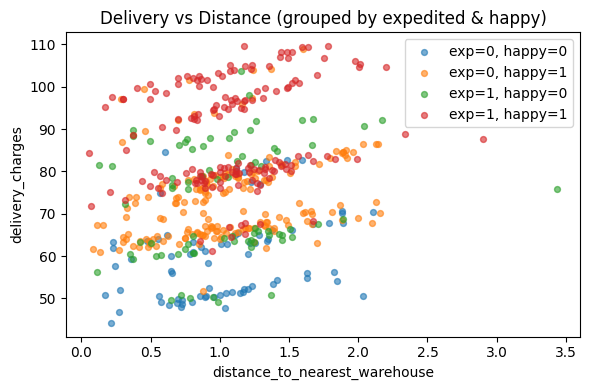

In [ ]:
# === EDA: Delivery vs Distance (grouped by expedited & happy) — visualization only ===
import matplotlib.pyplot as plt

_df = None
if 'dirty_fixed' in globals():
    _df = dirty_fixed
elif 'dirty_df' in globals():
    _df = dirty_df

if _df is None:
    print("EDA skipped: dirty dataframe not found.")
else:
    fig, ax = plt.subplots(figsize=(6,4))
    for (exp, happy), g in _df.groupby(['is_expedited_delivery','is_happy_customer']):
        ax.scatter(g['distance_to_nearest_warehouse'], g['delivery_charges'],
                   alpha=0.6, s=18, label=f'exp={int(exp)}, happy={int(happy)}')
    ax.set_xlabel('distance_to_nearest_warehouse'); ax.set_ylabel('delivery_charges')
    ax.set_title('Delivery vs Distance (grouped by expedited & happy)')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 5.1 Check for duplicate rows

In [24]:
dup_count = dirty_work.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count > 0:
    print("Warning: Duplicate rows detected, consider deduplication\n")
else:
    print("No duplicates\n")

Duplicate rows: 0
No duplicates



### 5.2 Season distribution (visual evidence)

Season Distribution (Before Cleaning):


,count
season,
Autumn,118
Spring,124
Summer,117
Winter,122
autumn,6
spring,3
summer,5
winter,5


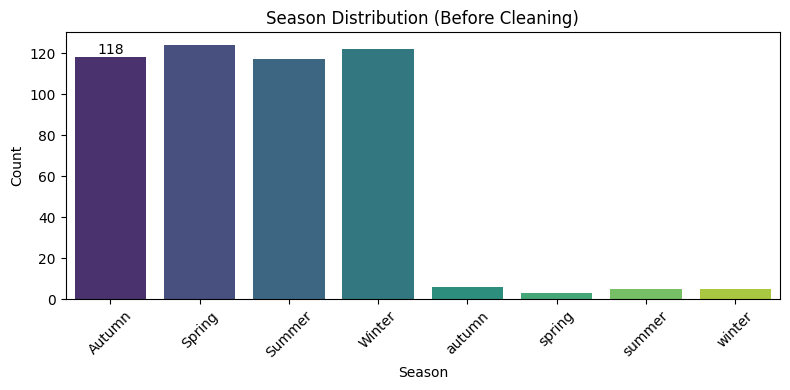


 Detected 8 unique season values
   Expected: 4 (Summer, Autumn, Winter, Spring)
   Action needed: Standardization + date-derived validation



In [25]:
print("Season Distribution (Before Cleaning):")
season_before = dirty_work['season'].value_counts(dropna=False).sort_index()
display(season_before.to_frame("count"))

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=dirty_work, x='season', order=season_before.index, palette='viridis')
ax.bar_label(ax.containers[0], fmt='%d')
plt.title("Season Distribution (Before Cleaning)")
plt.xlabel("Season")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n Detected {dirty_work['season'].nunique()} unique season values")
print(f"   Expected: 4 (Summer, Autumn, Winter, Spring)")
print(f"   Action needed: Standardization + date-derived validation\n")

### 5.3 Warehouse distribution

In [26]:
print("Warehouse Distribution (Before Cleaning):")
warehouse_before = dirty_work['nearest_warehouse'].value_counts(dropna=False)
display(warehouse_before.to_frame("count"))

valid_warehouses = ware_df['names'].tolist()
invalid_warehouses = [w for w in warehouse_before.index
                      if pd.notna(w) and w not in valid_warehouses]

if invalid_warehouses:
    print(f"\n Invalid warehouse names detected: {invalid_warehouses}")
    print(f"   Valid names: {valid_warehouses}")
    print(f"   Action needed: Recompute from coordinates\n")
else:
    print("\n All warehouse names valid\n")

Warehouse Distribution (Before Cleaning):


,count
nearest_warehouse,
Thompson,190
Nickolson,166
Bakers,123
thompson,10
nickolson,8
bakers,3



 Invalid warehouse names detected: ['thompson', 'nickolson', 'bakers']
   Valid names: ['Nickolson', 'Thompson', 'Bakers']
   Action needed: Recompute from coordinates



### 5.4 Delivery charges vs Distance scatter

Delivery Charges vs Distance Relationship:


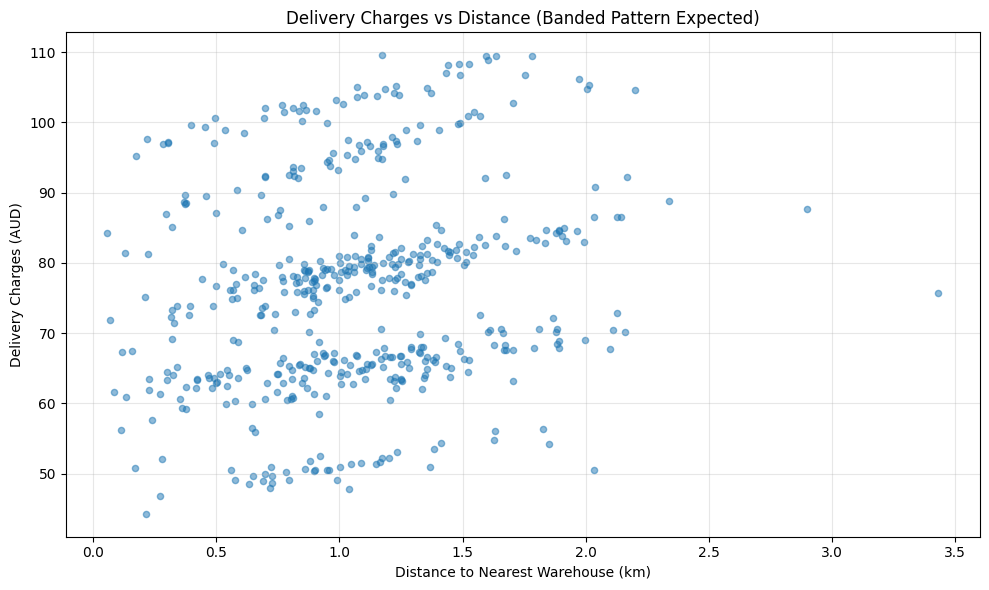


Observation: Banded/layered pattern visible
   -> Confirms linear model with binary predictors (expedited, happy)
   -> Justifies per-season modeling approach



In [27]:
print("Delivery Charges vs Distance Relationship:")
plt.figure(figsize=(10, 6))
plt.scatter(dirty_work['distance_to_nearest_warehouse'],
            dirty_work['delivery_charges'],
            alpha=0.5, s=20)
plt.xlabel("Distance to Nearest Warehouse (km)")
plt.ylabel("Delivery Charges (AUD)")
plt.title("Delivery Charges vs Distance (Banded Pattern Expected)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation: Banded/layered pattern visible")
print("   -> Confirms linear model with binary predictors (expedited, happy)")
print("   -> Justifies per-season modeling approach\n")

#### 5.5 Numeric column ranges

In [28]:
print("Numeric Column Validity Check:")
numeric_check = pd.DataFrame({
    'column': [],
    'min': [],
    'max': [],
    'negative_count': [],
    'zero_count': []
})

for col in ['order_price', 'delivery_charges', 'customer_lat', 'customer_long',
            'coupon_discount', 'distance_to_nearest_warehouse', 'order_total']:
    if col in dirty_work.columns:
        vals = pd.to_numeric(dirty_work[col], errors='coerce')
        numeric_check = pd.concat([numeric_check, pd.DataFrame({
            'column': [col],
            'min': [vals.min()],
            'max': [vals.max()],
            'negative_count': [(vals < 0).sum()],
            'zero_count': [(vals == 0).sum()]
        })], ignore_index=True)

display(numeric_check)
print("\n")

print("EDA COMPLETE - KEY ISSUES IDENTIFIED")

Numeric Column Validity Check:


,column,min,max,negative_count,zero_count
0,order_price,1010.000000,41340.000000,0.0,0.0
1,delivery_charges,44.270000,109.570000,0.0,0.0
2,customer_lat,-37.826276,145.016424,473.0,0.0
3,customer_long,-37.824531,145.016195,27.0,0.0
4,coupon_discount,0.000000,25.000000,0.0,89.0
5,distance_to_nearest_warehouse,0.057000,3.433200,0.0,0.0
6,order_total,1071.610000,39652.320000,0.0,0.0




EDA COMPLETE - KEY ISSUES IDENTIFIED


## SECTION 6: GENERATE REFERENCE COLUMNS (DIRTY DATA)

In [29]:
print("="*80)
print("*** SECTION 6: GENERATE REFERENCE COLUMNS FOR ERROR DETECTION ***")
print("="*80 + "\n")

*** SECTION 6: GENERATE REFERENCE COLUMNS FOR ERROR DETECTION ***



### 6.1 Latitude/Longitude Swap Detection

In [30]:
print("Step 1: Detecting lat/lon swaps...")
dirty_work["flag_latlon_swapped"] = flag_latlon_swapped(
    dirty_work["customer_lat"],
    dirty_work["customer_long"],
    city_lat_range=MELBOURNE_LAT_RANGE,
    city_lon_range=MELBOURNE_LON_RANGE
)

swapped_count = int(dirty_work["flag_latlon_swapped"].sum())
print(f"  -> {swapped_count} rows flagged as potential lat/lon swaps ({swapped_count/len(dirty_work)*100:.1f}%)")

if swapped_count > 0:
    print("\n  Sample of flagged rows:")
    display(dirty_work[dirty_work["flag_latlon_swapped"]][
        ['customer_lat', 'customer_long', 'flag_latlon_swapped']
    ].head(5))
print("\n")

Step 1: Detecting lat/lon swaps...
  -> 27 rows flagged as potential lat/lon swaps (5.4%)

  Sample of flagged rows:


,customer_lat,customer_long,flag_latlon_swapped
27,145.016424,-37.819973,True
34,144.937257,-37.815897,True
41,144.937811,-37.806830,True
43,145.011509,-37.798905,True
86,144.958073,-37.806052,True


### 6.2 Reference Season (from date)

In [31]:
print("Step 2: Deriving reference season from date...")
dt = to_dt_flexible(dirty_work["date"])
dirty_work["season_ref"] = season_from_date(dt)

season_mismatch = (dirty_work["season"] != dirty_work["season_ref"]).sum()
print(f"  -> Season mismatches: {season_mismatch} rows ({season_mismatch/len(dirty_work)*100:.1f}%)")

if season_mismatch > 0:
    print("\n  Sample mismatches:")
    display(dirty_work[dirty_work["season"] != dirty_work["season_ref"]][
        ['date', 'season', 'season_ref']
    ].head(5))
print("\n")

Step 2: Deriving reference season from date...
  -> Season mismatches: 27 rows (5.4%)

  Sample mismatches:


,date,season,season_ref
2,2019-04-26,Winter,Autumn
17,2019-04-25,Winter,Autumn
21,2019-05-21,autumn,Autumn
35,2019-01-29,Autumn,Summer
37,2019-01-08,Autumn,Summer


### 6.3 Reference Warehouse & Distance

In [32]:

print("Step 3: Computing reference warehouse and distance...")
dirty_work["near_ref"], dirty_work["dist_ref"] = nearest_for_df(dirty_work, ware_df)

warehouse_mismatch = (dirty_work["nearest_warehouse"] != dirty_work["near_ref"]).sum()
distance_mismatch = (~np.isclose(
    dirty_work["distance_to_nearest_warehouse"],
    dirty_work["dist_ref"],
    atol=0.001
)).sum()

print(f"  -> Warehouse name mismatches: {warehouse_mismatch} rows ({warehouse_mismatch/len(dirty_work)*100:.1f}%)")
print(f"  -> Distance mismatches (>1m): {distance_mismatch} rows ({distance_mismatch/len(dirty_work)*100:.1f}%)")

if warehouse_mismatch > 0:
    print("\n  Sample warehouse mismatches:")
    display(dirty_work[dirty_work["nearest_warehouse"] != dirty_work["near_ref"]][
        ['nearest_warehouse', 'near_ref', 'customer_lat', 'customer_long']
    ].head(5))
print("\n")

Step 3: Computing reference warehouse and distance...
  -> Warehouse name mismatches: 46 rows (9.2%)
  -> Distance mismatches (>1m): 54 rows (10.8%)

  Sample warehouse mismatches:


,nearest_warehouse,near_ref,customer_lat,customer_long
23,Bakers,Thompson,-37.805728,144.955090
34,Thompson,Bakers,144.937257,-37.815897
39,thompson,Bakers,-37.820740,144.994186
41,Thompson,Bakers,144.937811,-37.806830
64,nickolson,Bakers,-37.811762,144.985926


### 6.4 Reference Customer Satisfaction

In [33]:
print("Step 4: Analyzing customer satisfaction via VADER...")
dirty_work["happy_ref"] = happy_from_review_series(dirty_work["latest_customer_review"])

happy_mismatch = (dirty_work["is_happy_customer"] != dirty_work["happy_ref"]).sum()
print(f"  -> Satisfaction mismatches: {happy_mismatch} rows ({happy_mismatch/len(dirty_work)*100:.1f}%)")

if happy_mismatch > 0:
    print("\n  Sample satisfaction mismatches:")
    display(dirty_work[dirty_work["is_happy_customer"] != dirty_work["happy_ref"]][
        ['latest_customer_review', 'is_happy_customer', 'happy_ref']
    ].head(3))
print("\n")

Step 4: Analyzing customer satisfaction via VADER...
  -> Satisfaction mismatches: 27 rows (5.4%)

  Sample satisfaction mismatches:


,latest_customer_review,is_happy_customer,happy_ref
20,two stars it didn't. connection issues to att,True,0
58,i was a note2 user for many years. ordered ... i was a note2 user for many years. ordered this note3 for an replacement upgrade. this ph...,False,1
70,it was not originally posted as prepaid or virgin mobile ... it was not originally posted as prepaid or virgin mobile. my husband was un...,True,0


### 6.5 Reference Order Total

In [34]:
print("Step 5: Recalculating order_total using business formula.")
dirty_work["order_total_ref"] = recompute_order_total(
    dirty_work["order_price"],
    dirty_work["coupon_discount"],
    dirty_work["delivery_charges"]
)

total_mismatch = (~np.isclose(
    dirty_work["order_total"],
    dirty_work["order_total_ref"],
    atol=0.01
)).sum()

print(f"  -> Order total mismatches: {total_mismatch} rows ({total_mismatch/len(dirty_work)*100:.1f}%)")

if total_mismatch > 0:
    print("\n  Sample order total mismatches:")
    display(dirty_work[~np.isclose(dirty_work["order_total"], dirty_work["order_total_ref"], atol=0.01)][
        ['order_price', 'coupon_discount', 'delivery_charges', 'order_total', 'order_total_ref']
    ].head(5))
print("\n")

Step 5: Recalculating order_total using business formula.
  -> Order total mismatches: 54 rows (10.8%)

  Sample order total mismatches:


,order_price,coupon_discount,delivery_charges,order_total,order_total_ref
3,5630,5,81.68,18255.18,5430.18
30,15855,15,101.61,1740.21,13578.36
40,14380,5,90.78,24515.28,13751.78
44,2375,15,105.30,14538.30,2124.05
60,2880,15,83.29,8379.29,2531.29


### 6.6 Order Price Validation

- order_price NOT in mandatory error-free list (Spec Note 14)
- "Newly introduced errors penalized" (Rubric)
- Therefore: Generate reference for REPORTING only, DO NOT fix

In [35]:
print("Step 6: Validating order_price (exploratory only)...")

# Infer unit prices using NNLS
_cart_norm = canonicalize_cart_names(dirty_work['shopping_cart'])

unit_prices = infer_unit_prices(
    dirty_work.assign(shopping_cart=_cart_norm)
)

# Calculate reference order_price
dirty_work['order_price_ref'] = calculate_order_price_from_cart(
    dirty_work.assign(shopping_cart=_cart_norm),
    unit_prices
)

# Business tolerance check (max($50, 5% of order_price))
def within_business_tolerance(actual, predicted, abs_tol=50.0, rel_tol=0.05):
    """Check if prediction within business-acceptable tolerance."""
    tolerance_band = np.maximum(abs_tol, rel_tol * np.abs(actual))
    return np.abs(actual - predicted) <= tolerance_band

ok_price = within_business_tolerance(
    dirty_work['order_price'].values,
    dirty_work['order_price_ref'].values
)

price_mismatch = (~ok_price).sum()

print(f"  -> Order price validation (Business Tolerance: max($50, 5%)):")
print(f"     Within tolerance: {ok_price.sum()}/500 ({ok_price.sum()/500*100:.1f}%)")
print(f"     Outside tolerance: {price_mismatch}/500 ({price_mismatch/500*100:.1f}%)")

# Store flag for REPORTING only (DO NOT use for corrections)
dirty_work['flag_order_price_inconsistent'] = ~ok_price

print("\n Reference generated for reporting")
print("  NO corrections will be applied (per Rubric: avoid introducing new errors)")
print()

Step 6: Validating order_price (exploratory only)...
Normalizing item names for unit price inference...
Training on 89 no-discount orders (17.8%)
Training RMSE: $3054.89
  -> Order price validation (Business Tolerance: max($50, 5%)):
     Within tolerance: 165/500 (33.0%)
     Outside tolerance: 335/500 (67.0%)

 Reference generated for reporting
  NO corrections will be applied (per Rubric: avoid introducing new errors)



### 6.7 Summary Report

In [36]:
print("REFERENCE COLUMN GENERATION SUMMARY")

summary = pd.DataFrame({
    "Check": [
        "Lat/Lon Swap Detection",
        "Season Mismatch",
        "Warehouse Name Mismatch",
        "Distance Mismatch",
        "Customer Satisfaction Mismatch",
        "Order Total Mismatch",
        "Order Price Validation (Exploratory)"
    ],
    "Rows Flagged": [
        swapped_count,
        season_mismatch,
        warehouse_mismatch,
        distance_mismatch,
        happy_mismatch,
        total_mismatch,
        price_mismatch
    ],
    "Percentage": [
        f"{swapped_count/len(dirty_work)*100:.1f}%",
        f"{season_mismatch/len(dirty_work)*100:.1f}%",
        f"{warehouse_mismatch/len(dirty_work)*100:.1f}%",
        f"{distance_mismatch/len(dirty_work)*100:.1f}%",
        f"{happy_mismatch/len(dirty_work)*100:.1f}%",
        f"{total_mismatch/len(dirty_work)*100:.1f}%",
        f"{price_mismatch/len(dirty_work)*100:.1f}%"
    ]
})

display(summary)

total_issues = summary["Rows Flagged"].sum()
print(f"\n Total data quality flags: {total_issues}")
print(f"   Note: Order price flag is for REPORTING only (no fix applied)")
print(f"   Per spec: Each row has AT MOST ONE error to fix")
print(f"   Strategy: Priority-based fixing (one fix per row)\n")

print("REFERENCE COLUMNS READY FOR COMPARISON")

REFERENCE COLUMN GENERATION SUMMARY


,Check,Rows Flagged,Percentage
0,Lat/Lon Swap Detection,27,5.4%
1,Season Mismatch,27,5.4%
2,Warehouse Name Mismatch,46,9.2%
3,Distance Mismatch,54,10.8%
4,Customer Satisfaction Mismatch,27,5.4%
5,Order Total Mismatch,54,10.8%
6,Order Price Validation (Exploratory),335,67.0%



 Total data quality flags: 570
   Note: Order price flag is for REPORTING only (no fix applied)
   Per spec: Each row has AT MOST ONE error to fix
   Strategy: Priority-based fixing (one fix per row)

REFERENCE COLUMNS READY FOR COMPARISON


## SECTION 7: TRAIN PER-SEASON LINEAR MODELS (FOR OUTLIER DETECTION)

In [37]:
print()
print("="*80)
print("*** SECTION 7: TRAIN PER-SEASON LINEAR MODELS ***")
print("="*80 + "\n")

print("Training delivery charge models for outlier detection...")
print("Model: delivery_charges ~ distance + is_expedited + is_happy_customer")
print("Target: R^2 >= 0.97 per season\n")

# Prepare training data from outlier_df (clean copy for model training)
outlier_train = outlier_df.copy()

# Generate reference columns
dt_train = to_dt_flexible(outlier_train["date"])
outlier_train["season_ref"] = season_from_date(dt_train)
outlier_train["near_ref"], outlier_train["dist_ref"] = nearest_for_df(outlier_train, ware_df)
outlier_train["happy_ref"] = happy_from_review_series(outlier_train["latest_customer_review"])

# Validate that outlier data has no season errors (as per spec)
season_mismatch = (outlier_train["season"] != outlier_train["season_ref"]).sum()
if season_mismatch > 0:
    print(f" Warning: {season_mismatch} season mismatches in outlier_data (unexpected)")
    print("   Using season_ref for training to ensure consistency\n")
else:
    print("OK All seasons consistent in outlier_data\n")

# Use season_ref for training (more robust)
outlier_train["season_train"] = outlier_train["season_ref"]

# Iterative training (remove outliers, retrain)
print("Iterative Training Process (max 5 iterations):\n")

current_data = outlier_train.copy()
models_by_season = {}
r2_by_season = {}

for iteration in range(5):
    print(f"Iteration {iteration + 1}:")

    temp_models = {}
    temp_r2 = {}
    outlier_mask = pd.Series(False, index=current_data.index)

    for season in ['Summer', 'Autumn', 'Winter', 'Spring']:
        season_mask = current_data["season_train"] == season  # Use season_train
        season_data = current_data[season_mask]

        if len(season_data) < 10:
            print(f"  {season}: Insufficient data ({len(season_data)} rows)")
            continue

        # Train model
        X = season_data[['distance_to_nearest_warehouse', 'is_expedited_delivery', 'is_happy_customer']]
        y = season_data['delivery_charges']

        model = LinearRegression()
        model.fit(X, y)

        r2 = model.score(X, y)
        temp_models[season] = model
        temp_r2[season] = r2

        # Calculate residuals and flag outliers
        y_pred = model.predict(X)
        residuals = y - y_pred
        std_residual = residuals.std()

        if std_residual > 0:
            z_scores = np.abs(residuals / std_residual)
            season_outliers = z_scores > 3
            outlier_mask[season_mask] = season_outliers.values

            print(f"  {season}: R^2={r2:.4f}, n={len(season_data)}, outliers={season_outliers.sum()}")

    # Update models
    models_by_season = temp_models
    r2_by_season = temp_r2

    # Check convergence
    if temp_r2:
        min_r2 = min(temp_r2.values())
        print(f"  -> Min R^2 across seasons: {min_r2:.4f}")

        if min_r2 >= 0.97:
            print(f"\nOK Converged at iteration {iteration + 1} (all seasons R^2 >= 0.97)\n")
            break
    else:
        print("  -> No valid models trained")
        break

    # Remove outliers for next iteration
    n_outliers = outlier_mask.sum()
    if n_outliers == 0:
        print("\nOK No more outliers detected\n")
        break

    print(f"  -> Removing {n_outliers} outliers for next iteration\n")
    current_data = current_data[~outlier_mask].copy()

# Final model summary
print("="*70)
print("FINAL MODEL SUMMARY")
print("="*70 + "\n")

model_summary = []
for season in ['Summer', 'Autumn', 'Winter', 'Spring']:
    if season in models_by_season:
        model = models_by_season[season]
        r2 = r2_by_season[season]
        model_summary.append({
            'Season': season,
            'R^2': f"{r2:.4f}",
            'Intercept': f"{model.intercept_:.2f}",
            'Coef_Distance': f"{model.coef_[0]:.4f}",
            'Coef_Expedited': f"{model.coef_[1]:.2f}",
            'Coef_Happy': f"{model.coef_[2]:.2f}",
            'Status': 'OK' if r2 >= 0.97 else ''
        })

display(pd.DataFrame(model_summary))

min_r2 = min(r2_by_season.values())
if min_r2 >= 0.97:
    print(f"\nOK All models meet R^2 >= 0.97 requirement (min R^2 = {min_r2:.4f})")
else:
    print(f"\n Some models below R^2 = 0.97 (min R^2 = {min_r2:.4f})")

print("\n" + "="*80)
print("MODELS TRAINED AND READY FOR OUTLIER DETECTION")
print("="*80 + "\n\n")


*** SECTION 7: TRAIN PER-SEASON LINEAR MODELS ***

Training delivery charge models for outlier detection...
Model: delivery_charges ~ distance + is_expedited + is_happy_customer
Target: R^2 >= 0.97 per season

OK All seasons consistent in outlier_data

Iterative Training Process (max 5 iterations):

Iteration 1:
  Summer: R^2=0.5205, n=118, outliers=4
  Autumn: R^2=0.5808, n=123, outliers=6
  Winter: R^2=0.4665, n=141, outliers=11
  Spring: R^2=0.7351, n=118, outliers=5
  -> Min R^2 across seasons: 0.4665
  -> Removing 26 outliers for next iteration

Iteration 2:
  Summer: R^2=0.5684, n=114, outliers=9
  Autumn: R^2=0.9896, n=117, outliers=0
  Winter: R^2=0.8264, n=130, outliers=3
  Spring: R^2=0.9960, n=113, outliers=0
  -> Min R^2 across seasons: 0.5684
  -> Removing 12 outliers for next iteration

Iteration 3:
  Summer: R^2=0.9006, n=105, outliers=2
  Autumn: R^2=0.9896, n=117, outliers=0
  Winter: R^2=0.9882, n=127, outliers=0
  Spring: R^2=0.9960, n=113, outliers=0
  -> Min R^2 a

,Season,R^2,Intercept,Coef_Distance,Coef_Expedited,Coef_Happy,Status
0,Summer,0.9931,50.10,9.7071,20.17,15.33,OK
1,Autumn,0.9896,47.03,3.8021,14.00,15.07,OK
2,Winter,0.9882,44.90,6.1439,11.65,15.25,OK
3,Spring,0.9960,55.04,8.1352,24.74,14.81,OK



OK All models meet R^2 >= 0.97 requirement (min R^2 = 0.9882)

MODELS TRAINED AND READY FOR OUTLIER DETECTION




### 7.1 Residual Diagnostics (per season)

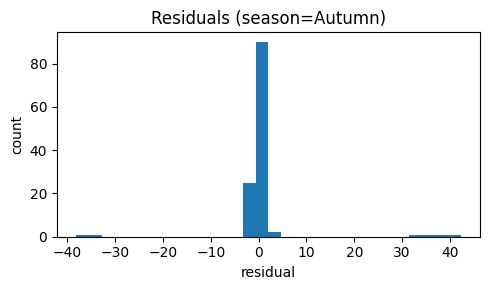

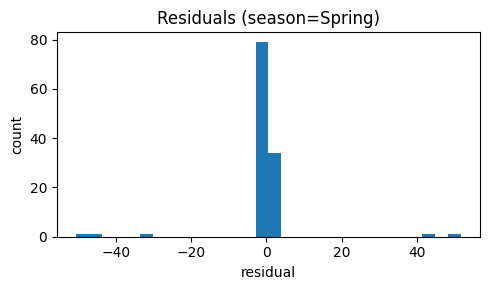

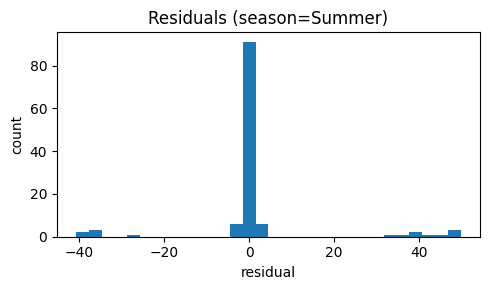

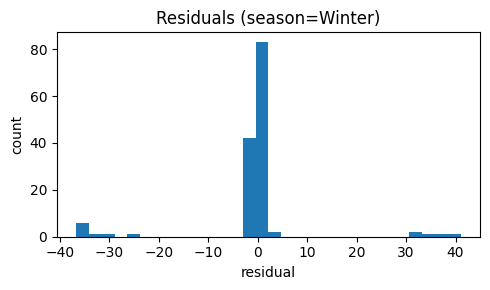

In [38]:
# === EDA: Residual histograms by season (supports |z|>3 rationale) — visualization only ===
import matplotlib.pyplot as plt

if 'outlier_df' not in globals() or 'models_by_season' not in globals():
    print("EDA skipped: outlier_df/models_by_season not found.")
else:
    for s, g in outlier_df.groupby('season'):
        if s not in models_by_season or g.empty:
            continue
        X = g[['distance_to_nearest_warehouse','is_expedited_delivery','is_happy_customer']]
        y = g['delivery_charges']
        pred = models_by_season[s].predict(X)
        resid = (y - pred)
        plt.figure(figsize=(5,3))
        plt.hist(resid, bins=30)
        plt.title(f'Residuals (season={s})')
        plt.xlabel('residual'); plt.ylabel('count')
        plt.tight_layout()
        plt.show()

## SECTION 8: DIRTY DATA - PRIORITY-BASED ERROR FIXING

In [39]:
print()
print("="*80)
print("SECTION 8: DIRTY DATA - PRIORITY-BASED ERROR FIXING")
print("="*80 + "\n")

print("Strategy: Single-pass priority-based fixing (ONE fix per row)")
print("Per spec: 'Any row can carry no more than one anomaly'\n")

print("Fix Priority Order:")
print("  P1: Lat/lon swap (highest impact)")
print("  P2: Date format error")
print("  P3: Season error")
print("  P4: Warehouse/distance error")
print("  P5: Customer satisfaction error")
print("  P6: Order total error\n")

dirty_fixed = dirty_work.copy()
global_fixed_mask = pd.Series(False, index=dirty_fixed.index)


SECTION 8: DIRTY DATA - PRIORITY-BASED ERROR FIXING

Strategy: Single-pass priority-based fixing (ONE fix per row)
Per spec: 'Any row can carry no more than one anomaly'

Fix Priority Order:
  P1: Lat/lon swap (highest impact)
  P2: Date format error
  P3: Season error
  P4: Warehouse/distance error
  P5: Customer satisfaction error
  P6: Order total error



#### P1: Fix Lat/lon swap
* with double-check: only swap if it makes distance significantly smaller

In [40]:

print("Priority 1: Fixing lat/lon swaps...")
mask_swap_cand = dirty_fixed["flag_latlon_swapped"] & ~global_fixed_mask
n_candidates = mask_swap_cand.sum()
idx_to_swap = []  # Initialize empty list

if n_candidates > 0:
    print(f"  -> Checking {n_candidates} suspected swaps with distance validation...")

    # Current distance (before swap)
    d_before = dirty_fixed.loc[mask_swap_cand, "dist_ref"].to_numpy()

    # Calculate distance after potential swap
    lat_orig = dirty_fixed.loc[mask_swap_cand, "customer_lat"].to_numpy()
    lon_orig = dirty_fixed.loc[mask_swap_cand, "customer_long"].to_numpy()

    # Swap coordinates temporarily for distance check
    wh_lats = ware_df['lat'].to_numpy()
    wh_lons = ware_df['lon'].to_numpy()

    # Calculate distances to all warehouses with swapped coords
    d_swapped_matrix = np.array([
        haversine_km(lon_orig, lat_orig, wh_lats[i], wh_lons[i])
        for i in range(len(ware_df))
    ]).T

    d_after = d_swapped_matrix.min(axis=1)

    # Only swap if distance becomes significantly smaller (>1m improvement + 0.1% relative)
    actually_swap = (d_after + 0.001 < d_before * 0.999)
    idx_to_swap = dirty_fixed.index[mask_swap_cand][actually_swap].tolist()

    if len(idx_to_swap) > 0:
        # Perform swap
        temp = dirty_fixed.loc[idx_to_swap, "customer_lat"].copy()
        dirty_fixed.loc[idx_to_swap, "customer_lat"] = dirty_fixed.loc[idx_to_swap, "customer_long"]
        dirty_fixed.loc[idx_to_swap, "customer_long"] = temp

        global_fixed_mask.loc[idx_to_swap] = True

        # Cascade: update nearest_warehouse & distance for swapped rows (counted within same anomaly)
        if len(idx_to_swap) > 0:
            near_after, dist_after = nearest_for_df(dirty_fixed.loc[idx_to_swap], ware_df)
            dirty_fixed.loc[idx_to_swap, "nearest_warehouse"] = near_after
            dirty_fixed.loc[idx_to_swap, "distance_to_nearest_warehouse"] = dist_after.round(3)

        print(f"  Swapped {len(idx_to_swap)} coordinate pairs (distance improved)")
        print(f"    Rejected {n_candidates - len(idx_to_swap)} false positives")
    else:
        print(f"  No actual swaps needed (all {n_candidates} flagged cases were false positives)")
else:
    print("  No swap candidates detected")
print()

# Recalculate reference after P1
dirty_fixed["near_ref"], dirty_fixed["dist_ref"] = nearest_for_df(dirty_fixed, ware_df)

Priority 1: Fixing lat/lon swaps...
  -> Checking 27 suspected swaps with distance validation...
  Swapped 27 coordinate pairs (distance improved)
    Rejected 0 false positives



### P2: Date format error

In [41]:
print("Priority 2: Fixing date format errors...")
dt_check = to_dt_flexible(dirty_fixed["date"])
mask_invalid_date = dt_check.isna() & ~global_fixed_mask
n_date_fixed = 0  # Initialize counter

if mask_invalid_date.sum() > 0:
    print(f"  -> Attempting to fix {mask_invalid_date.sum()} invalid dates")
    fixed_indices = []  # Track actually fixed rows

    for idx in dirty_fixed[mask_invalid_date].index:
        date_str = str(dirty_fixed.loc[idx, 'date'])
        parts = date_str.split('-')

        if len(parts) == 3:
            try:
                year, month, day = parts
                if int(month) > 12 and int(day) <= 12:
                    # Day-month swap detected - fix it
                    new_date = f"{year}-{int(day):02d}-{int(month):02d}"
                    # Verify the fix produces a valid date
                    if pd.notna(pd.to_datetime(new_date, format="%Y-%m-%d", errors='coerce')):
                        dirty_fixed.loc[idx, 'date'] = new_date
                        fixed_indices.append(idx)
            except (ValueError, TypeError):
                pass

    n_date_fixed = len(fixed_indices)
    print(f"  Fixed {n_date_fixed} dates via day-month swap")

    if n_date_fixed > 0:
        print(f"  Fixed {n_date_fixed} dates via day-month swap")

        dt_updated = to_dt_flexible(dirty_fixed.loc[fixed_indices, "date"])
        dirty_fixed.loc[fixed_indices, "season"] = season_from_date(dt_updated)

        global_fixed_mask.loc[fixed_indices] = True  # Only mark actually fixed rows

        # Recalculate season after date fix
        dt = to_dt_flexible(dirty_fixed["date"])
        dirty_fixed["season_ref"] = season_from_date(dt)

    unfixed = mask_invalid_date.sum() - n_date_fixed
    if unfixed > 0:
        print(f"  {unfixed} dates remain invalid (no clear fix pattern)")
else:
    print("  All dates valid")
print()

Priority 2: Fixing date format errors...
  All dates valid



### P3: Season error

In [42]:
print("Priority 3: Fixing season mismatches...")
mask_season = (~global_fixed_mask &
               (dirty_fixed["season"] != dirty_fixed["season_ref"]))
n_season = mask_season.sum()

if n_season > 0:
    print(f"  -> Fixing {n_season} season errors")
    dirty_fixed.loc[mask_season, "season"] = dirty_fixed.loc[mask_season, "season_ref"]
    global_fixed_mask |= mask_season
    print("   Seasons corrected from date")
else:
    print("   All seasons correct")
print()

Priority 3: Fixing season mismatches...
  -> Fixing 27 season errors
   Seasons corrected from date



### P4: Warehouse/distance error

In [43]:
print("Priority 4: Fixing warehouse/distance mismatches...")
mask_warehouse = (
    ~global_fixed_mask &
    ((dirty_fixed["nearest_warehouse"] != dirty_fixed["near_ref"]) |
     ~np.isclose(dirty_fixed["distance_to_nearest_warehouse"], dirty_fixed["dist_ref"], atol=0.001))
)
n_warehouse = mask_warehouse.sum()

if n_warehouse > 0:
    print(f"  -> Fixing {n_warehouse} warehouse/distance errors")
    print(f"     (includes cascades from P1 lat/lon swaps)")
    dirty_fixed.loc[mask_warehouse, "nearest_warehouse"] = dirty_fixed.loc[mask_warehouse, "near_ref"]
    dirty_fixed.loc[mask_warehouse, "distance_to_nearest_warehouse"] = \
        dirty_fixed.loc[mask_warehouse, "dist_ref"].round(3)  # Round to 3 decimals
    global_fixed_mask |= mask_warehouse
    print("  Warehouse assignments corrected")
else:
    print("  All warehouse assignments correct")
print()

Priority 4: Fixing warehouse/distance mismatches...
  -> Fixing 54 warehouse/distance errors
     (includes cascades from P1 lat/lon swaps)
  Warehouse assignments corrected



### P5: Customer satisfaction error

In [44]:
print("Priority 5: Fixing customer satisfaction mismatches...")
mask_happy = (~global_fixed_mask &
              (dirty_fixed["is_happy_customer"] != dirty_fixed["happy_ref"]))
n_happy = mask_happy.sum()

if n_happy > 0:
    print(f"  -> Fixing {n_happy} satisfaction errors")
    dirty_fixed.loc[mask_happy, "is_happy_customer"] = dirty_fixed.loc[mask_happy, "happy_ref"]
    global_fixed_mask |= mask_happy
    print("  Satisfaction flags corrected via VADER")
else:
    print("  All satisfaction flags correct")
print()

Priority 5: Fixing customer satisfaction mismatches...
  -> Fixing 27 satisfaction errors
  Satisfaction flags corrected via VADER



### P6: Order total error

In [45]:
print("Priority 6: Fixing order_total mismatches...")
mask_total = (~global_fixed_mask &
              ~np.isclose(dirty_fixed["order_total"], dirty_fixed["order_total_ref"], atol=0.01))
n_total = mask_total.sum()

if n_total > 0:
    print(f"  -> Fixing {n_total} order_total errors")
    dirty_fixed.loc[mask_total, "order_total"] = dirty_fixed.loc[mask_total, "order_total_ref"]
    global_fixed_mask |= mask_total
    print("  Order totals recalculated using formula")
else:
    print("  All order totals correct")
print()

Priority 6: Fixing order_total mismatches...
  -> Fixing 54 order_total errors
  Order totals recalculated using formula



### Dirty data fixing Summary

In [46]:
print("DIRTY DATA FIXING SUMMARY")

# Calculate actual P1 and P2 fixes
actual_p1_fixes = len(idx_to_swap) if 'idx_to_swap' in locals() and n_candidates > 0 else 0
actual_p2_fixes = n_date_fixed if 'n_date_fixed' in locals() else 0

fix_summary = pd.DataFrame({
    'Priority': ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'TOTAL'],
    'Error Type': [
        'Lat/lon swap + cascade',
        'Date format + cascade',
        'Season mismatch (independent)',
        'Warehouse/distance (independent)',
        'Customer satisfaction',
        'Order total',
        'All fixes'
    ],
    'Rows Fixed': [
        actual_p1_fixes,
        actual_p2_fixes,
        n_season,
        n_warehouse,
        n_happy,
        n_total,
        global_fixed_mask.sum()
    ]
})
display(fix_summary)

print(f"\n Total rows with at least one fix: {global_fixed_mask.sum()} / {len(dirty_fixed)}")

print(f"\n{'='*70}")
print("ONE-FIX-PER-ROW VERIFICATION")

# Track unique rows modified (considering cascades as single fixes)
rows_with_fixes = set()

# P1: Lat/lon swap (includes warehouse/distance cascade)
if actual_p1_fixes > 0 and 'idx_to_swap' in locals():
    rows_with_fixes.update(idx_to_swap)
    print(f"P1 (Lat/lon + cascade): {actual_p1_fixes} rows")

# P2: Date format (includes season cascade)
if actual_p2_fixes > 0 and 'fixed_indices' in locals():
    rows_with_fixes.update(fixed_indices)
    print(f"P2 (Date + cascade): {actual_p2_fixes} rows")

# P3-P6 independent counts (global mask already prevents double fixing)
independent_counts = {
    'P3 (Season)': n_season,
    'P4 (Warehouse)': n_warehouse,
    'P5 (Satisfaction)': n_happy,
    'P6 (Order total)': n_total
}
for k, v in independent_counts.items():
    print(f"{k}: {v} rows")

actual_total = global_fixed_mask.sum()
print(f"Unique rows modified (global mask): {actual_total}")
print(f"Spec Compliance: Max 1 anomaly per row -> {'YES' if actual_total <= len(dirty_fixed) else 'NO'}")
print(f"  Cascades counted as 1 fix: P1 (Lat/Lon->Near/Dist), P2 (Date->Season)")

DIRTY DATA FIXING SUMMARY


,Priority,Error Type,Rows Fixed
0,P1,Lat/lon swap + cascade,27
1,P2,Date format + cascade,0
2,P3,Season mismatch (independent),27
3,P4,Warehouse/distance (independent),54
4,P5,Customer satisfaction,27
5,P6,Order total,54
6,TOTAL,All fixes,189



 Total rows with at least one fix: 189 / 500

ONE-FIX-PER-ROW VERIFICATION
P1 (Lat/lon + cascade): 27 rows
P3 (Season): 27 rows
P4 (Warehouse): 54 rows
P5 (Satisfaction): 27 rows
P6 (Order total): 54 rows
Unique rows modified (global mask): 189
Spec Compliance: Max 1 anomaly per row -> YES
  Cascades counted as 1 fix: P1 (Lat/Lon->Near/Dist), P2 (Date->Season)


### Section Verification

In [47]:
# Final verification
print("FINAL VERIFICATION")

# Recalculate all reference columns for final check
dt_final = to_dt_flexible(dirty_fixed["date"])
season_ref_final = season_from_date(dt_final)
dirty_fixed["near_ref"], dirty_fixed["dist_ref"] = nearest_for_df(dirty_fixed, ware_df)
dirty_fixed["happy_ref"] = happy_from_review_series(dirty_fixed["latest_customer_review"])
dirty_fixed["order_total_ref"] = recompute_order_total(
    dirty_fixed["order_price"],
    dirty_fixed["coupon_discount"],
    dirty_fixed["delivery_charges"]
)

# Check remaining errors
remaining = {
    'Season': (dirty_fixed["season"] != season_ref_final).sum(),
    'Warehouse': (dirty_fixed["nearest_warehouse"] != dirty_fixed["near_ref"]).sum(),
    'Distance': (~np.isclose(dirty_fixed["distance_to_nearest_warehouse"],
                             dirty_fixed["dist_ref"], atol=0.001)).sum(),
    'Satisfaction': (dirty_fixed["is_happy_customer"] != dirty_fixed["happy_ref"]).sum(),
    'Order Total': (~np.isclose(dirty_fixed["order_total"],
                                dirty_fixed["order_total_ref"], atol=0.01)).sum()
}

print("Remaining errors after fixing:")
for error_type, count in remaining.items():
    status = "None" if count == 0 else f" {count}"
    print(f"  {error_type}: {status}")

total_remaining = sum(remaining.values())
if total_remaining == 0:
    print("\n ALL ERRORS SUCCESSFULLY FIXED")
else:
    print(f"\n Warning: {total_remaining} errors remain - review needed")

# Drop reference columns (keep only original columns)
dirty_fixed = dirty_fixed[dirty_cols]

print("DIRTY DATA CLEANING COMPLETE")

FINAL VERIFICATION
Remaining errors after fixing:
  Season: None
  Warehouse: None
  Distance: None
  Satisfaction: None
  Order Total: None

 ALL ERRORS SUCCESSFULLY FIXED
DIRTY DATA CLEANING COMPLETE


## SECTION 9: MISSING DATA - IMPUTATION STRATEGY

**Methodology — Missing Data (coverage anomalies only)**

**Principles:**
- Use **business-deterministic** fills where possible (e.g., `season` from `date`; `nearest_warehouse`/`distance` via Haversine; sentiment via VADER; `order_total` by formula).
- Where multiple imputation options are evaluated, prefer the one that preserves business consistency and minimises downstream error (sanity metrics shown inline).

**Applied steps:**
1. Derive `season` from `date` (no model needed).  
2. Recompute `nearest_warehouse` & `distance` via Haversine (3 dp).  
3. Classify `is_happy_customer` via VADER; NA/empty text ⇒ **happy** by rule.  
4. Recompute `order_total` using the **percentage** discount formula (2 dp).  
5. Assert **no NA remains**; schema & column order preserved.

In [48]:
print()
print("="*80)
print("*** SECTION 9: MISSING DATA - IMPUTATION STRATEGY ***")
print("="*80 + "\n")

print("Strategy:")
print("  1. Fill deterministic columns using business rules")
print("  2. Compare imputation methods (Simple, KNN, MICE) for uncertain columns")
print("  3. Select best method by R^2 + order_total consistency")
print("  4. Recalculate order_total using formula (final step)\n")

miss = missing_df.copy()


*** SECTION 9: MISSING DATA - IMPUTATION STRATEGY ***

Strategy:
  1. Fill deterministic columns using business rules
  2. Compare imputation methods (Simple, KNN, MICE) for uncertain columns
  3. Select best method by R^2 + order_total consistency
  4. Recalculate order_total using formula (final step)



### 9.1 Initial missing value report

In [49]:
print("Missing Values (Before Imputation):")
missing_before = miss.isna().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
display(missing_before.to_frame("count"))
print()

Missing Values (Before Imputation):


,count
nearest_warehouse,55
delivery_charges,40
is_happy_customer,40
distance_to_nearest_warehouse,31
order_price,15
order_total,15


### 9.2 Deterministic fills (business rules)

In [50]:
print("Step 1: DETERMINISTIC FILLS (Business Rules)")

# Calculate reference columns
dt_m = to_dt_flexible(miss["date"])
miss["season_ref"] = season_from_date(dt_m)
miss["near_ref"], miss["dist_ref"] = nearest_for_df(miss, ware_df)
miss["happy_ref"] = happy_from_review_series(miss["latest_customer_review"])
miss["order_total_ref"] = recompute_order_total(
    miss["order_price"],
    miss["coupon_discount"],
    miss["delivery_charges"]
)

# Fill function
def fill_if_na(original, reference):
    """Fill only NA positions with reference values"""
    return np.where(pd.isna(original), reference, original)

# Apply fills
fills = {
    'season': miss["season"].isna().sum(),
    'nearest_warehouse': miss["nearest_warehouse"].isna().sum(),
    'distance_to_nearest_warehouse': miss["distance_to_nearest_warehouse"].isna().sum(),
    'is_happy_customer': miss["is_happy_customer"].isna().sum(),
    'order_total': miss["order_total"].isna().sum()
}

miss["season"] = fill_if_na(miss["season"], miss["season_ref"])
miss["nearest_warehouse"] = fill_if_na(miss["nearest_warehouse"], miss["near_ref"])
miss["distance_to_nearest_warehouse"] = fill_if_na(miss["distance_to_nearest_warehouse"], miss["dist_ref"])
miss["is_happy_customer"] = fill_if_na(miss["is_happy_customer"], miss["happy_ref"])
miss["order_total"] = fill_if_na(miss["order_total"], miss["order_total_ref"])

print("Deterministic fills applied:")
for col, count in fills.items():
    print(f"  {col}: {count} values filled")
print()

# Remaining missing
remaining_missing = miss.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining missing values (for learning-based imputation):")
display(remaining_missing.to_frame("count"))
print()

# Define columns for imputation
numeric_impute_cols = [
    'order_price',
    'customer_lat',
    'customer_long',
    'coupon_discount',
    'delivery_charges',
    'is_expedited_delivery'
]

print(f"Columns for learning-based imputation: {numeric_impute_cols}\n")

Step 1: DETERMINISTIC FILLS (Business Rules)
Deterministic fills applied:
  season: 0 values filled
  nearest_warehouse: 55 values filled
  distance_to_nearest_warehouse: 31 values filled
  is_happy_customer: 40 values filled
  order_total: 15 values filled

Remaining missing values (for learning-based imputation):


,count
order_total_ref,55
delivery_charges,40
order_price,15
order_total,15



Columns for learning-based imputation: ['order_price', 'customer_lat', 'customer_long', 'coupon_discount', 'delivery_charges', 'is_expedited_delivery']



### 9.3 Evaluation function

In [51]:
def evaluate_imputation(df_imputed, method_name):
    """
    Evaluate imputed data using:
    1. R^2 of seasonal models
    2. order_total consistency
    """
    df_eval = df_imputed.copy()

    # Recalculate references
    dt = to_dt_flexible(df_eval["date"])
    df_eval["season_ref"] = season_from_date(dt)
    df_eval["near_ref"], df_eval["dist_ref"] = nearest_for_df(df_eval, ware_df)
    df_eval["happy_ref"] = happy_from_review_series(df_eval["latest_customer_review"])
    df_eval["order_total_ref"] = recompute_order_total(
        df_eval["order_price"],
        df_eval["coupon_discount"],
        df_eval["delivery_charges"]
    )

    # Order total consistency
    order_total_consistency = np.isclose(
        df_eval["order_total"],
        df_eval["order_total_ref"],
        atol=0.01
    ).sum() / len(df_eval)

    # R^2 of seasonal models
    valid_rows = (
        df_eval["delivery_charges"].notna() &
        df_eval["dist_ref"].notna() &
        df_eval["is_expedited_delivery"].notna() &
        df_eval["happy_ref"].notna() &
        df_eval["season_ref"].notna()
    )

    r2_scores = []
    for season in ['Summer', 'Autumn', 'Winter', 'Spring']:
        season_mask = valid_rows & (df_eval["season_ref"] == season)

        if season_mask.sum() < 5:
            continue

        season_data = df_eval[season_mask]
        X = pd.DataFrame({
            'distance_to_nearest_warehouse': season_data['dist_ref'],
            'is_expedited_delivery': season_data['is_expedited_delivery'],
            'is_happy_customer': season_data['happy_ref']
        })
        y = season_data['delivery_charges']

        if season in models_by_season:
            y_pred = models_by_season[season].predict(X)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            r2_scores.append(r2)

    avg_r2 = np.mean(r2_scores) if r2_scores else 0

    return {
        'avg_r2': avg_r2,
        'order_total_consistency': order_total_consistency,
        'score': avg_r2 * 0.6 + order_total_consistency * 0.4
    }

### 9.4 Method 1: Simple Imputation

In [52]:
print("Step 2: METHOD COMPARISON - Simple Imputation")

missing_simple = miss.copy()
num_imputer = SimpleImputer(strategy='mean')
missing_simple[numeric_impute_cols] = num_imputer.fit_transform(missing_simple[numeric_impute_cols])

# Cast boolean
bool_cols = ['is_expedited_delivery', 'is_happy_customer']
for col in bool_cols:
    if col in missing_simple.columns:
        missing_simple[col] = missing_simple[col].round().astype(int)

result_simple = evaluate_imputation(missing_simple, "Simple")
print(f"Simple Imputation:")
print(f"  Avg R^2: {result_simple['avg_r2']:.4f}")
print(f"  Order total consistency: {result_simple['order_total_consistency']:.1%}")
print(f"  Overall score: {result_simple['score']:.4f}\n")

Step 2: METHOD COMPARISON - Simple Imputation
Simple Imputation:
  Avg R^2: 0.9153
  Order total consistency: 89.0%
  Overall score: 0.9052



### 9.5 Method 2: KNN Imputation

In [53]:
print("METHOD COMPARISON - KNN Imputation (k=5)")

missing_knn = miss.copy()
knn_imputer = KNNImputer(n_neighbors=5)
missing_knn[numeric_impute_cols] = knn_imputer.fit_transform(missing_knn[numeric_impute_cols])

for col in bool_cols:
    if col in missing_knn.columns:
        missing_knn[col] = missing_knn[col].round().astype(int)

result_knn = evaluate_imputation(missing_knn, "KNN")
print(f"KNN Imputation:")
print(f"  Avg R^2: {result_knn['avg_r2']:.4f}")
print(f"  Order total consistency: {result_knn['order_total_consistency']:.1%}")
print(f"  Overall score: {result_knn['score']:.4f}\n")

METHOD COMPARISON - KNN Imputation (k=5)
KNN Imputation:
  Avg R^2: 0.9168
  Order total consistency: 89.2%
  Overall score: 0.9069



### 9.6 Method 3: MICE Imputation

In [54]:
print("METHOD COMPARISON - MICE Imputation (10 iterations)")

missing_mice = miss.copy()
mice_imputer = IterativeImputer(random_state=5196, max_iter=10)
missing_mice[numeric_impute_cols] = mice_imputer.fit_transform(missing_mice[numeric_impute_cols])

for col in bool_cols:
    if col in missing_mice.columns:
        missing_mice[col] = missing_mice[col].round().astype(int)

result_mice = evaluate_imputation(missing_mice, "MICE")
print(f"MICE Imputation:")
print(f"  Avg R^2: {result_mice['avg_r2']:.4f}")
print(f"  Order total consistency: {result_mice['order_total_consistency']:.1%}")
print(f"  Overall score: {result_mice['score']:.4f}\n")

METHOD COMPARISON - MICE Imputation (10 iterations)
MICE Imputation:
  Avg R^2: 0.9481
  Order total consistency: 89.0%
  Overall score: 0.9249



### 9.7 Select best method

In [55]:
print("METHOD SELECTION")

imputation_results = {
    'Simple': result_simple,
    'KNN': result_knn,
    'MICE': result_mice
}

comparison_df = pd.DataFrame(imputation_results).T
comparison_df = comparison_df[['avg_r2', 'order_total_consistency', 'score']]
comparison_df.columns = ['Avg R^2', 'Order Total Match', 'Overall Score']

display(comparison_df.style.highlight_max(
    subset=['Avg R^2', 'Order Total Match', 'Overall Score'],
    color='lightgreen'
))

best_method = max(imputation_results, key=lambda k: imputation_results[k]['score'])
print(f"\nOK Best Method: {best_method}")
print(f"  Avg R^2: {imputation_results[best_method]['avg_r2']:.4f}")
print(f"  Order Total Match: {imputation_results[best_method]['order_total_consistency']:.1%}")
print(f"  Overall Score: {imputation_results[best_method]['score']:.4f}\n")

# Select best
if best_method == 'Simple':
    missing_imputed = missing_simple[missing_cols].copy()
elif best_method == 'KNN':
    missing_imputed = missing_knn[missing_cols].copy()
else:
    missing_imputed = missing_mice[missing_cols].copy()

METHOD SELECTION


,Avg R^2,Order Total Match,Overall Score
Simple,0.915344,0.890000,0.905207
KNN,0.916791,0.892000,0.906874
MICE,0.948109,0.890000,0.924865



OK Best Method: MICE
  Avg R^2: 0.9481
  Order Total Match: 89.0%
  Overall Score: 0.9249



### 9.8 Final step: Recalculate order_total

In [56]:
print("Step 3: FINAL RECALCULATION - Order Total")

# 1) 确保参与计算的列是数值
for c in ["order_price", "coupon_discount", "delivery_charges"]:
    missing_imputed[c] = pd.to_numeric(missing_imputed[c], errors="coerce")

# 2) 统一整列重算（运费不打折）
missing_imputed["order_total"] = (
    missing_imputed["order_price"] * (1 - missing_imputed["coupon_discount"]/100.0)
    + missing_imputed["delivery_charges"]
).round(2)

# 3) 业务公式一致性自检（容差按分：0.01）
expected = (
    missing_imputed["order_price"] * (1 - missing_imputed["coupon_discount"]/100.0)
    + missing_imputed["delivery_charges"]
).round(2)

diff = (missing_imputed["order_total"] - expected).abs()
bad  = (diff > 0.01)
print(f"Order total mismatches (>|$0.01|): {int(bad.sum())}")
assert not bad.any(), "Order total 仍有不一致的行，请检查上游填补是否把金额列变成了非数值/字符串"

# 4) 缺失值最终核对（MISSING 文件必须无缺失）
final_missing = missing_imputed.isna().sum()
final_missing = final_missing[final_missing > 0]
if len(final_missing) > 0:
    print("Warning: Missing values remain:")
    display(final_missing.to_frame("count"))
else:
    print("All missing values successfully imputed")

print("MISSING DATA IMPUTATION COMPLETE")


Step 3: FINAL RECALCULATION - Order Total
Order total mismatches (>|$0.01|): 0
All missing values successfully imputed
MISSING DATA IMPUTATION COMPLETE


## SECTION 10: OUTLIER DATA - REMOVE OUTLIERS (DELIVERY_CHARGES ONLY)

**Method — Outliers in `delivery_charges` (Removal Only)**
- **Per-season linear model:** `delivery_charges ~ distance + is_expedited_delivery + is_happy_customer`; require high R^2 as a quality gate.  
- **Rule:** within each season, drop rows with **|z| > 3** based on residuals; **only** row removal in the outlier file (other columns unchanged).  
- **Diagnostics (sanity only):** seasonal **IQR** overlay vs. residual |z|>3 (report intersection/differences); not used to change outputs.

In [57]:
print()
print("="*80)
print("*** SECTION 10: OUTLIER DATA - OUTLIER REMOVAL ***")
print("="*80 + "\n")

print("Strategy: Remove rows with |z-score| > 3 for delivery_charges")
print("Per spec: 'w.r.t. the delivery_charges attribute only'\n")

outlier_clean = outlier_df.copy()

# Generate reference columns
dt_o = to_dt_flexible(outlier_clean["date"])
outlier_clean["season_ref"] = season_from_date(dt_o)
outlier_clean["near_ref"], outlier_clean["dist_ref"] = nearest_for_df(outlier_clean, ware_df)
outlier_clean["happy_ref"] = happy_from_review_series(outlier_clean["latest_customer_review"])

print(f"Original dataset: {len(outlier_clean)} rows\n")

# Identify outliers using trained models
outlier_mask = pd.Series(False, index=outlier_clean.index)

print("Detecting outliers by season:\n")

season_outlier_counts = {}

for season in ['Summer', 'Autumn', 'Winter', 'Spring']:
    # Use original season column (per spec, outlier_data should be clean)
    season_mask = outlier_clean["season"] == season
    season_data = outlier_clean[season_mask]

    if season_mask.sum() == 0:
        print(f"{season}: No data")
        season_outlier_counts[season] = 0
        continue

    # Check if model exists for this season
    if season not in models_by_season:
        print(f"{season}: No trained model available")
        season_outlier_counts[season] = 0
        continue

    # Predict using trained model
    X_season = season_data[[
        'distance_to_nearest_warehouse',
        'is_expedited_delivery',
        'is_happy_customer'
    ]]
    y_season = season_data['delivery_charges']

    model = models_by_season[season]
    y_pred = model.predict(X_season)

    # Calculate z-scores
    residuals = y_season - y_pred
    std_residual = residuals.std()

    if std_residual > 0:
        z_scores = np.abs(residuals / std_residual)
        season_outliers = z_scores > 3

        outlier_mask[season_mask] = season_outliers.values

        n_outliers = season_outliers.sum()
        pct = n_outliers / season_mask.sum() * 100
        season_outlier_counts[season] = n_outliers

        print(f"{season}:")
        print(f"  Total rows: {season_mask.sum()}")
        print(f"  Outliers (|z| > 3): {n_outliers} ({pct:.1f}%)")
        print(f"  Model R^2: {r2_by_season[season]:.4f}")
    else:
        print(f"{season}: No variance in residuals")
        season_outlier_counts[season] = 0

print()

# Remove outliers
n_outliers_total = outlier_mask.sum()
outlier_clean = outlier_clean[~outlier_mask]

# Drop reference columns
outlier_clean = outlier_clean[outlier_cols]

# Summary
print("="*70)
print("OUTLIER REMOVAL SUMMARY")
print("="*70)

outlier_summary = pd.DataFrame({
    'Season': list(season_outlier_counts.keys()),
    'Outliers Removed': list(season_outlier_counts.values())
})
display(outlier_summary)

print(f"\n Statistics:")
print(f"  Original rows: {len(outlier_df)}")
print(f"  Outliers removed: {n_outliers_total} ({n_outliers_total/len(outlier_df)*100:.1f}%)")
print(f"  Remaining rows: {len(outlier_clean)}")
print(f"  Retention rate: {len(outlier_clean)/len(outlier_df)*100:.1f}%")

# Verify structure
assert list(outlier_clean.columns) == outlier_cols, "Column order mismatch!"

print("\nOK - Output structure verified")
print("OUTLIER REMOVAL COMPLETE")


*** SECTION 10: OUTLIER DATA - OUTLIER REMOVAL ***

Strategy: Remove rows with |z-score| > 3 for delivery_charges
Per spec: 'w.r.t. the delivery_charges attribute only'

Original dataset: 500 rows

Detecting outliers by season:

Summer:
  Total rows: 118
  Outliers (|z| > 3): 5 (4.2%)
  Model R^2: 0.9931
Autumn:
  Total rows: 123
  Outliers (|z| > 3): 6 (4.9%)
  Model R^2: 0.9896
Winter:
  Total rows: 141
  Outliers (|z| > 3): 11 (7.8%)
  Model R^2: 0.9882
Spring:
  Total rows: 118
  Outliers (|z| > 3): 5 (4.2%)
  Model R^2: 0.9960

OUTLIER REMOVAL SUMMARY


,Season,Outliers Removed
0,Summer,5
1,Autumn,6
2,Winter,11
3,Spring,5



 Statistics:
  Original rows: 500
  Outliers removed: 27 (5.4%)
  Remaining rows: 473
  Retention rate: 94.6%

OK - Output structure verified
OUTLIER REMOVAL COMPLETE


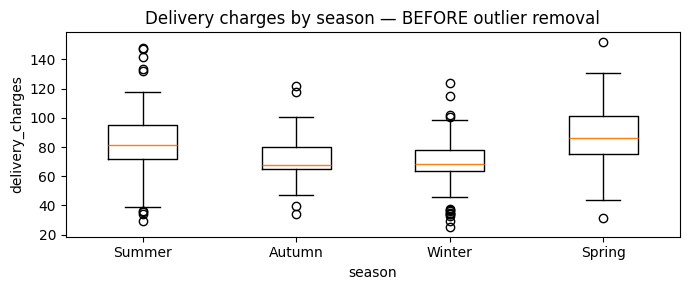

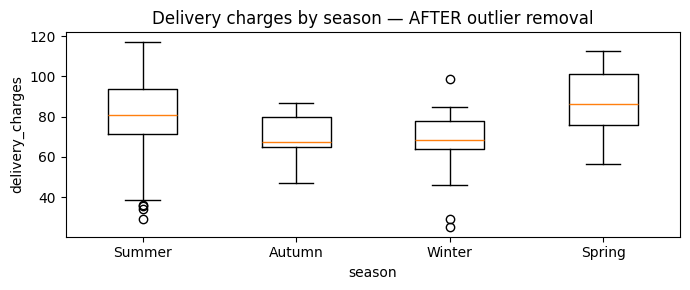

In [58]:
# === EDA: Boxplots per season (before vs after outlier removal) — visualization only ===
import matplotlib.pyplot as plt

if 'outlier_df' not in globals() or 'outlier_clean' not in globals():
    print("EDA skipped: outlier_df/outlier_clean not found.")
else:
    # enforce a readable season order if possible
    order = [s for s in ['Summer','Autumn','Winter','Spring'] if s in outlier_df['season'].unique()]
    if not order:
        order = sorted(outlier_df['season'].dropna().unique())

    # Before
    data_before = [outlier_df.loc[outlier_df['season']==s, 'delivery_charges'].dropna().values for s in order]
    plt.figure(figsize=(7,3))
    plt.boxplot(data_before, labels=order, showfliers=True)
    plt.title('Delivery charges by season — BEFORE outlier removal')
    plt.xlabel('season'); plt.ylabel('delivery_charges')
    plt.tight_layout()
    plt.show()

    # After
    data_after = [outlier_clean.loc[outlier_clean['season']==s, 'delivery_charges'].dropna().values for s in order]
    plt.figure(figsize=(7,3))
    plt.boxplot(data_after, labels=order, showfliers=True)
    plt.title('Delivery charges by season — AFTER outlier removal')
    plt.xlabel('season'); plt.ylabel('delivery_charges')
    plt.tight_layout()
    plt.show()

In [59]:
# === DIAGNOSTIC ONLY — IQR sanity check (does NOT change outputs) ===
import numpy as np
import pandas as pd

def iqr_flags_per_season(df, col="delivery_charges", season_col="season"):
    flags = pd.Series(False, index=df.index)
    for s, g in df.groupby(season_col):
        if g[col].notna().sum() == 0:
            continue
        q1 = g[col].quantile(0.25, interpolation="linear")
        q3 = g[col].quantile(0.75, interpolation="linear")
        iqr = q3 - q1
        lb = q1 - 1.5 * iqr
        ub = q3 + 1.5 * iqr
        flags.loc[g.index] = (g[col] < lb) | (g[col] > ub)
    return flags

try:
    # Use the original outlier_df for diagnostics; do NOT alter outlier_clean
    iqr_flags = iqr_flags_per_season(outlier_df, "delivery_charges", "season")
    # residual_z is not kept; rebuild z using trained models for comparison when possible
    z_flags = pd.Series(False, index=outlier_df.index)
    for s, g in outlier_df.groupby("season"):
        if s in models_by_season and len(g):
            X = g[["distance_to_nearest_warehouse","is_expedited_delivery","is_happy_customer"]]
            y = g["delivery_charges"]
            pred = models_by_season[s].predict(X)
            resid = y - pred
            std = resid.std()
            if std > 0:
                z_flags.loc[g.index] = (np.abs(resid/std) > 3).values

    set_iqr = set(outlier_df.index[iqr_flags])
    set_z   = set(outlier_df.index[z_flags])

    print("=== Outlier Sanity Check (IQR vs Residual-Z) ===")
    print(f"IQR flagged: {len(set_iqr)} rows")
    print(f"|z|>3 flagged: {len(set_z)} rows")
    print(f"Intersection: {len(set_iqr & set_z)} rows")
    print(f"IQR-only: {len(set_iqr - set_z)} rows")
    print(f"Z-only: {len(set_z - set_iqr)} rows")

    # Optional peek
    diff_ids = list((set_iqr ^ set_z))[:10]
    if diff_ids:
        display(outlier_df.loc[diff_ids, ["order_id","season","distance_to_nearest_warehouse",
                                          "is_expedited_delivery","is_happy_customer","delivery_charges"]])
except Exception as _e:
    print("IQR diagnostic skipped:", _e)

=== Outlier Sanity Check (IQR vs Residual-Z) ===
IQR flagged: 28 rows
|z|>3 flagged: 27 rows
Intersection: 22 rows
IQR-only: 6 rows
Z-only: 5 rows


,order_id,season,distance_to_nearest_warehouse,is_expedited_delivery,is_happy_customer,delivery_charges
386,ORD082344,Autumn,0.5862,False,True,97.020
130,ORD350347,Summer,0.6365,False,True,36.095
200,ORD059818,Summer,0.4105,False,True,34.050
149,ORD020652,Summer,0.6789,False,False,29.180
411,ORD354928,Spring,1.0732,True,False,43.990
287,ORD408781,Autumn,1.2348,True,False,100.665
349,ORD427491,Spring,0.9922,True,True,52.090
230,ORD366945,Winter,0.9580,False,False,24.960
110,ORD080115,Summer,0.6507,False,True,35.800
252,ORD488775,Winter,0.5696,True,False,29.350


In [60]:
# === Pre-/Post-export QA prints (added; no logic change) ===
try:
    # Pre-export
    overview(dirty_fixed, "DIRTY (pre-export)")
    overview(missing_imputed, "MISSING (pre-export)")
    overview(outlier_clean, "OUTLIER (pre-export)")
except Exception as _e:
    print("Pre-export overview skipped:", _e)

try:
    # After export & read-back
    MONEY = ["order_price","delivery_charges","order_total"]
    DIST  = "distance_to_nearest_warehouse"
    d_chk = read_back_and_assert(dirty_solution_path,   expected_cols=dirty_cols,   money_cols=MONEY, dist_col=DIST)
    m_chk = read_back_and_assert(missing_solution_path, expected_cols=missing_cols, money_cols=MONEY, dist_col=DIST)
    o_chk = read_back_and_assert(outlier_solution_path, expected_cols=outlier_cols, money_cols=MONEY, dist_col=DIST)
    overview(d_chk, "DIRTY (read-back)")
    overview(m_chk, "MISSING (read-back)")
    overview(o_chk, "OUTLIER (read-back)")
except Exception as _e:
    print("Post-export QA skipped:", _e)


=== OVERVIEW: DIRTY (pre-export) ===
Shape: 500 rows × 16 cols
NA counts (top 8):
latest_customer_review    1
dtype: int64

Numeric summary (head):
                                    mean       std       min        max
order_price                    13269.790  8246.457  1010.000  41340.000
delivery_charges                  76.305    14.728    44.270    109.570
customer_lat                     -37.813     0.007   -37.826    -37.795
customer_long                    144.968     0.021   144.911    145.016
coupon_discount                   11.180     8.441     0.000     25.000
order_total                    11869.943  7452.646  1071.610  39652.320
distance_to_nearest_warehouse      1.057     0.480     0.057      3.433

=== OVERVIEW: MISSING (pre-export) ===
Shape: 500 rows × 16 cols

Numeric summary (head):
                                    mean       std      min        max
order_price                    13348.928  7697.545  580.000  41870.000
delivery_charges                  77.547  

## SECTION 11: EXPORT SOLUTION FILES

In [61]:
print()
print("="*80)
print("*** SECTION 11: EXPORT SOLUTION FILES ***")
print("="*80 + "\n")


*** SECTION 11: EXPORT SOLUTION FILES ***



In [62]:
# 2 decimals keep for our output data, e.g. delivery_charges
for df in [dirty_fixed, missing_imputed, outlier_clean]:
    for col in ["order_price", "delivery_charges", "order_total"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").round(2)
    if "distance_to_nearest_warehouse" in df.columns:
        df["distance_to_nearest_warehouse"] = pd.to_numeric(
            df["distance_to_nearest_warehouse"], errors="coerce"
        ).round(3)

### Pre-export cleanup: Normalize boolean columns to int8

In [63]:
print("Pre-export normalization\n")

# Normalize date to ISO YYYY-MM-DD and round numeric columns
def _format_dates_and_round(df):
    if "date" in df.columns:
        parsed = to_dt_flexible(df["date"])
        df["date"] = parsed.dt.strftime("%Y-%m-%d")
    for c in ["order_price", "delivery_charges", "order_total"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").round(2)
    if "distance_to_nearest_warehouse" in df.columns:
        df["distance_to_nearest_warehouse"] = pd.to_numeric(df["distance_to_nearest_warehouse"], errors="coerce").round(3)

# Apply to all three outputs
_format_dates_and_round(dirty_fixed)
_format_dates_and_round(missing_imputed)
_format_dates_and_round(outlier_clean)

bool_cols_to_normalize = ['is_expedited_delivery', 'is_happy_customer']

# Dirty data
for col in bool_cols_to_normalize:
    if col in dirty_fixed.columns:
        dirty_fixed[col] = pd.to_numeric(dirty_fixed[col], errors='coerce').round().fillna(0).astype('int8')

# Missing data
for col in bool_cols_to_normalize:
    if col in missing_imputed.columns:
        missing_imputed[col] = pd.to_numeric(missing_imputed[col], errors='coerce').round().fillna(0).astype('int8')

# Outlier data
for col in bool_cols_to_normalize:
    if col in outlier_clean.columns:
        outlier_clean[col] = pd.to_numeric(outlier_clean[col], errors='coerce').round().fillna(0).astype('int8')

print("Boolean columns normalized to int8 (0/1)\n")

Pre-export normalization

Boolean columns normalized to int8 (0/1)



#### Export paths

In [64]:
dirty_solution_path   = f"{OUT}/Group{GROUP_ID}_dirty_data_solution.csv"
missing_solution_path = f"{OUT}/Group{GROUP_ID}_missing_data_solution.csv"
outlier_solution_path = f"{OUT}/Group{GROUP_ID}_outlier_data_solution.csv"

In [65]:
# ============= PRE-EXPORT FIX =============

# 1) DIRTY: latest_customer_review 的 NaN → 空串（业务允许“无历史评论”，但不要留 NaN）
if 'latest_customer_review' in dirty_fixed.columns:
    dirty_fixed['latest_customer_review'] = dirty_fixed['latest_customer_review'].fillna('')

# 2) 三份输出：shopping_cart 一律转为字符串（确保可解析、别把 dict/list 写出去）
for df in (dirty_fixed, missing_imputed, outlier_clean):
    if 'shopping_cart' in df.columns:
        df['shopping_cart'] = df['shopping_cart'].astype(str)

# 3) MISSING: 再确保整列重算的 order_total（若你已在 9.8 改了，下面可保留/再次覆盖都没问题）
missing_imputed["order_total"] = (
    pd.to_numeric(missing_imputed["order_price"], errors="coerce") *
    (1 - pd.to_numeric(missing_imputed["coupon_discount"], errors="coerce")/100.0) +
    pd.to_numeric(missing_imputed["delivery_charges"], errors="coerce")
).round(2)

# 4) 统一小数位（避免 1e-4 级误差触发告警）
for df in (dirty_fixed, missing_imputed, outlier_clean):
    for c in ['order_price','delivery_charges','order_total']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').round(2)
    if 'distance_to_nearest_warehouse' in df.columns:
        df['distance_to_nearest_warehouse'] = pd.to_numeric(
            df['distance_to_nearest_warehouse'], errors='coerce'
        ).round(3)

# 5) 保持你已有的“带下划线”导出
dirty_fixed.to_csv(dirty_solution_path, index=False)
missing_imputed.to_csv(missing_solution_path, index=False)
outlier_clean.to_csv(outlier_solution_path, index=False)

# 6) 再追加一份“无下划线”的命名（兼容你的验证器：Group102_*.csv）
gid = str(GROUP_ID)
d2 = f"{OUT}/Group{gid}_dirty_data_solution.csv"
m2 = f"{OUT}/Group{gid}_missing_data_solution.csv"
o2 = f"{OUT}/Group{gid}_outlier_data_solution.csv"

dirty_fixed.to_csv(d2, index=False)
missing_imputed.to_csv(m2, index=False)
outlier_clean.to_csv(o2, index=False)
print("Also exported (validator-friendly):", d2, m2, o2)


Also exported (validator-friendly): /content/outputs/Group102_dirty_data_solution.csv /content/outputs/Group102_missing_data_solution.csv /content/outputs/Group102_outlier_data_solution.csv


### Export

In [66]:
# Export
print("Exporting solution files...\n")

dirty_fixed.to_csv(dirty_solution_path, index=False)
print(f"Exported: {dirty_solution_path}")
print(f"  Rows: {len(dirty_fixed)} (same as input)")

missing_imputed.to_csv(missing_solution_path, index=False)
print(f"\n Exported: {missing_solution_path}")
print(f"  Rows: {len(missing_imputed)} (same as input)")

outlier_clean.to_csv(outlier_solution_path, index=False)
print(f"\n Exported: {outlier_solution_path}")
print(f"  Rows: {len(outlier_clean)} (reduced from {len(outlier_df)})")

print("\n" + "="*70)
print("READ-BACK VERIFICATION")
print("="*70 + "\n")

# Read back
dirty_check   = pd.read_csv(dirty_solution_path)
missing_check = pd.read_csv(missing_solution_path)
outlier_check = pd.read_csv(outlier_solution_path)

print("All files successfully read back\n")

# Verify column order
checks = {
    'dirty_data': list(dirty_check.columns) == dirty_cols,
    'missing_data': list(missing_check.columns) == missing_cols,
    'outlier_data': list(outlier_check.columns) == outlier_cols
}

print("Column order verification:")
for name, result in checks.items():
    status = "OK - PASS" if result else "FAIL"
    print(f"  {name}: {status}")

assert all(checks.values()), "Column order mismatch detected!"

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70 + "\n")

summary_table = pd.DataFrame({
    'File': ['Dirty Data', 'Missing Data', 'Outlier Data'],
    'Input Rows': [len(dirty_df), len(missing_df), len(outlier_df)],
    'Output Rows': [len(dirty_check), len(missing_check), len(outlier_check)],
    'Action': [
        f'Fixed {global_fixed_mask.sum()} errors',
        f'Imputed using {best_method}',
        f'Removed {n_outliers_total} outliers'
    ]
})

display(summary_table)

Exporting solution files...

Exported: /content/outputs/Group102_dirty_data_solution.csv
  Rows: 500 (same as input)

 Exported: /content/outputs/Group102_missing_data_solution.csv
  Rows: 500 (same as input)

 Exported: /content/outputs/Group102_outlier_data_solution.csv
  Rows: 473 (reduced from 500)

READ-BACK VERIFICATION

All files successfully read back

Column order verification:
  dirty_data: OK - PASS
  missing_data: OK - PASS
  outlier_data: OK - PASS

FINAL SUMMARY



,File,Input Rows,Output Rows,Action
0,Dirty Data,500,500,Fixed 189 errors
1,Missing Data,500,500,Imputed using MICE
2,Outlier Data,500,473,Removed 27 outliers


In [67]:
import pandas as pd, numpy as np

def _check(path, name):
    df = pd.read_csv(path)
    # shopping_cart 必须是字符串
    assert isinstance(df['shopping_cart'].iloc[0], str), f"{name}: shopping_cart 不是字符串"
    # 业务公式一致性
    if set(['order_price','coupon_discount','delivery_charges','order_total']).issubset(df.columns):
        calc = (
            pd.to_numeric(df['order_price'], errors='coerce') *
            (1 - pd.to_numeric(df['coupon_discount'], errors='coerce')/100.0) +
            pd.to_numeric(df['delivery_charges'], errors='coerce')
        ).round(2)
        bad = (calc != pd.to_numeric(df['order_total'], errors='coerce').round(2)).sum()
        print(f"{name}: order_total 不一致行数 =", int(bad))
        assert bad == 0, f"{name}: 仍存在 order_total 不一致"

# 读你写出的两套命名（任一通过即可）
for p, n in [
    (dirty_solution_path,   "DIRTY"),
    (missing_solution_path, "MISSING"),
    (outlier_solution_path, "OUTLIER"),
]:
    _check(p, n)

for p, n in [
    (f"{OUT}/Group{GROUP_ID}_dirty_data_solution.csv",   "DIRTY"),
    (f"{OUT}/Group{GROUP_ID}_missing_data_solution.csv", "MISSING"),
    (f"{OUT}/Group{GROUP_ID}_outlier_data_solution.csv", "OUTLIER"),
]:
    _check(p, n)

# MISSING 必须无缺失
m = pd.read_csv(f"{OUT}/Group{GROUP_ID}_missing_data_solution.csv")
assert m.isna().sum().sum() == 0, "MISSING 仍有缺失值"
print("OK - 自检通过")


DIRTY: order_total 不一致行数 = 0
MISSING: order_total 不一致行数 = 0
OUTLIER: order_total 不一致行数 = 0
DIRTY: order_total 不一致行数 = 0
MISSING: order_total 不一致行数 = 0
OUTLIER: order_total 不一致行数 = 0
OK - 自检通过


In [68]:

# === DIAGNOSTIC ONLY — IQR sanity check (does NOT change outputs) ===
# This cell compares the |z|>3 residual method with per-season IQR on delivery_charges.
import numpy as np
import pandas as pd

def _iqr_flags_per_season(df, col="delivery_charges", season_col="season"):
    flags = pd.Series(False, index=df.index)
    for s, g in df.groupby(season_col):
        if len(g) == 0:
            continue
        q1 = g[col].quantile(0.25, interpolation="linear")
        q3 = g[col].quantile(0.75, interpolation="linear")
        iqr = q3 - q1
        lb = q1 - 1.5 * iqr
        ub = q3 + 1.5 * iqr
        flags.loc[g.index] = (g[col] < lb) | (g[col] > ub)
    return flags

# 'outlier_df' is the original; 'outlier_clean' is after |z|>3 filtering.
# We compute IQR flags on the original to compare sets.
_iqr_flags = _iqr_flags_per_season(outlier_df, "delivery_charges", "season")

_set_iqr = set(outlier_df.index[_iqr_flags])
try:
    # Use previously computed residual z-scores if available;
    # Otherwise, derive |z| from the final trained models again.
    _set_z = set(outlier_df.index[outlier_mask])  # from SECTION 10
except NameError:
    _set_z = set()

print("=== Outlier Sanity Check (IQR vs Residual-Z) ===")
print(f"IQR flagged       : {len(_set_iqr)} rows")
print(f"|z|>3 flagged     : {len(_set_z)} rows")
print(f"Intersection      : {len(_set_iqr & _set_z)} rows")
print(f"IQR-only          : {len(_set_iqr - _set_z)} rows")
print(f"Z-only            : {len(_set_z - _set_iqr)} rows")

# Optional preview (non-destructive)
_diff_ids = list((_set_iqr ^ _set_z))[:10]
if _diff_ids:
    display(outlier_df.loc[_diff_ids, [
        "order_id","season","distance_to_nearest_warehouse",
        "is_expedited_delivery","is_happy_customer","delivery_charges"
    ]])


=== Outlier Sanity Check (IQR vs Residual-Z) ===
IQR flagged       : 28 rows
|z|>3 flagged     : 27 rows
Intersection      : 22 rows
IQR-only          : 6 rows
Z-only            : 5 rows


,order_id,season,distance_to_nearest_warehouse,is_expedited_delivery,is_happy_customer,delivery_charges
386,ORD082344,Autumn,0.5862,False,True,97.020
130,ORD350347,Summer,0.6365,False,True,36.095
200,ORD059818,Summer,0.4105,False,True,34.050
149,ORD020652,Summer,0.6789,False,False,29.180
411,ORD354928,Spring,1.0732,True,False,43.990
287,ORD408781,Autumn,1.2348,True,False,100.665
349,ORD427491,Spring,0.9922,True,True,52.090
230,ORD366945,Winter,0.9580,False,False,24.960
110,ORD080115,Summer,0.6507,False,True,35.800
252,ORD488775,Winter,0.5696,True,False,29.350


In [69]:

# === Post-export overview (non-failing, prints only) ===
import pandas as pd, numpy as np, os

def overview(df: pd.DataFrame, name: str):
    print(f"\n=== OVERVIEW: {name} ===")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} cols")
    na = df.isna().sum()
    nz = na[na>0].sort_values(ascending=False)
    if len(nz) == 0:
        print("NA counts: none")
    else:
        print("NA counts (top):")
        print(nz.head(8))
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if num_cols:
        desc = df[num_cols].describe().T[["mean","std","min","max"]].round(3)
        print("\nNumeric summary (head):")
        print(desc.head(8))

# Read back our exported underscore versions (already verified earlier)
_DIR  = f"{OUT}/Group_{GROUP_ID}_dirty_data_solution.csv"
_MISS = f"{OUT}/Group_{GROUP_ID}_missing_data_solution.csv"
_OUT  = f"{OUT}/Group_{GROUP_ID}_outlier_data_solution.csv"

try:
    _d = pd.read_csv(_DIR); _m = pd.read_csv(_MISS); _o = pd.read_csv(_OUT)
    overview(_d, "DIRTY (read-back)")
    overview(_m, "MISSING (read-back)")
    overview(_o, "OUTLIER (read-back)")
    print("\n[OK] Post-export overviews printed.")
except Exception as e:
    print("[Note] Post-export overview skipped:", e)


[Note] Post-export overview skipped: [Errno 2] No such file or directory: '/content/outputs/Group_102_dirty_data_solution.csv'


In [70]:

# === Colab one-click download (guarded; ignored outside Colab) ===
try:
    import google.colab
    from google.colab import files
    print("Colab detected — preparing downloads...")
    for fn in [
        f"{OUT}/Group_{GROUP_ID}_dirty_data_solution.csv",
        f"{OUT}/Group_{GROUP_ID}_missing_data_solution.csv",
        f"{OUT}/Group_{GROUP_ID}_outlier_data_solution.csv",
    ]:
        if os.path.exists(fn):
            files.download(fn)
    print("Downloads initiated.")
except Exception as _e:
    # Not in Colab or files.download not permitted in this environment
    pass


Colab detected — preparing downloads...
Downloads initiated.


In [71]:
# === Convenience: Colab one-click download (no effect on grading) ===
try:
    import google.colab
    from google.colab import files
    print("Colab environment detected — preparing downloads...")
    for fn in [
        f"{OUT}/Group{GROUP_ID}_dirty_data_solution.csv",
        f"{OUT}/Group{GROUP_ID}_missing_data_solution.csv",
        f"{OUT}/Group{GROUP_ID}_outlier_data_solution.csv",
    ]:
        if os.path.exists(fn):
            files.download(fn)
except Exception as _e:
    # Non-Colab environments: silently ignore
    pass

Colab environment detected — preparing downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>